# Import

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import re

import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.covariance import LedoitWolf

from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
#plt.style.use('seaborn-v0_8-darkgrid')
from dashboard import PortfolioDashboardVisualizer
import cvxpy as cp


import QuantLib as ql
from functools import lru_cache

from finance import get_calendar, COUNTRY_DEFAULT_FREQ_MAP

from signal_model import (
    SignalConfig,
    compute_roll_bp_1m,
    orthogonalize_roll_vs_carry,
    apply_roll_to_signal,
    estimate_expected_returns_from_long,
)

import warnings

warnings.filterwarnings(
    "ignore",
    message="Values in x were outside bounds during a minimize step, clipping to bounds",
    category=RuntimeWarning,
)


## Helpers QuantLib

In [2]:

@lru_cache(maxsize=None)
def _build_bond(issue_date, maturity_date, coupon_dec, freq, country_iso):
    """
    Construit et cache un FixedRateBond QuantLib + liste des cashflows (dates/amounts).
    Face = 100, settlementDays=0 (carry calculé "trade-date", simple et stable).
    """
    cal = get_calendar(country_iso)

    daycount = ql.ActualActual(ql.ActualActual.ISMA)

    issue_ql = ql.Date(issue_date.day, issue_date.month, issue_date.year)
    mat_ql   = ql.Date(maturity_date.day, maturity_date.month, maturity_date.year)

    frequency = {1: ql.Annual, 2: ql.Semiannual, 4: ql.Quarterly}.get(int(freq), ql.Semiannual)

    schedule = ql.Schedule(
        issue_ql,
        mat_ql,
        ql.Period(frequency),
        cal,
        ql.Following,
        ql.Following,
        ql.DateGeneration.Backward,
        False,
    )

    face = 100.0
    bond = ql.FixedRateBond(0, face, schedule, [float(coupon_dec)], daycount)

    cfs = [(cf.date(), float(cf.amount())) for cf in bond.cashflows() if isinstance(cf, ql.Coupon)]
    cfs.sort(key=lambda x: x[0])

    return bond, cfs


def _compute_carry_for_isin(df_isin):
    """
    carry journalier (unité "return" / notional) = (Δaccrued + coupons payés) / 100
    sur l'intervalle (t_{k-1}, t_k].
    """
    df = df_isin.sort_values("time_stamp").copy()

    # Si metadata manquante, on retourne sur l'ancienne approximation
    if (df["issue_date"].isna().all() or df["maturity_date"].isna().all() or df["coupon_dec"].isna().all()):
        df["pnl_carry"] = (df["price"] / 100.0) * df["y_dec"] / 252.0
        return df

    issue_date    = df["issue_date"].iloc[0]
    maturity_date = df["maturity_date"].iloc[0]
    coupon_dec    = float(df["coupon_dec"].iloc[0])
    freq          = int(df["cpn_freq"].iloc[0])
    country_iso   = df["country_iso"].iloc[0]

    
    bond, cfs = _build_bond(issue_date, maturity_date, coupon_dec, freq, country_iso)

    cf_dates = [d for d, _ in cfs]
    cf_amts  = [a for _, a in cfs]

    carry = np.zeros(len(df), dtype=float)

    prev_ql = None
    accrued_prev = None
    k = 0  # pointeur cashflows

    for i, ts in enumerate(df["time_stamp"].tolist()):
        d = ql.Date(ts.day, ts.month, ts.year)

        accrued = float(bond.accruedAmount(d))  # en currency units sur face=100

        if prev_ql is None:
            carry[i] = 0.0
            # on ignore tout cashflow <= première date
            while k < len(cf_dates) and cf_dates[k] <= d:
                k += 1
        else:
            coupons = 0.0
            # ajoute les cashflows dans (prev_ql, d]
            while k < len(cf_dates) and cf_dates[k] <= d:
                coupons += cf_amts[k]
                k += 1

            carry_amount_px = (accrued - accrued_prev) + coupons  # "price points" sur base 100
            carry[i] = carry_amount_px / 100.0                   # -> return / notional

        prev_ql = d
        accrued_prev = accrued

    df["pnl_carry"] = carry
    return df


In [3]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

data["time_stamp"] = pd.to_datetime(data["time_stamp"])

data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
print(data.shape)
data.head()

(26622, 10)


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961


In [4]:
mid_bonds_close = pd.read_csv("data/mid_bonds_close_it_de_fr.csv")
mid_bonds_close.head()

,date,isin,yield
0,2023-11-09 00:00:00+00:00,IT0005445306,3.8200
1,2023-12-07 00:00:00+00:00,DE0001102564,2.0770
2,2023-12-22 00:00:00+00:00,FR0014004J31,2.9480
3,2023-11-24 00:00:00+00:00,DE0001135226,2.6785
4,2023-11-30 00:00:00+00:00,DE0001030559,0.2970



## Chargement des coupons par bond

In [5]:
meta = pd.read_csv("data/metadata_bonds.csv")

meta["issue_date"] = pd.to_datetime(meta["issue_date"], errors="coerce").dt.date
meta["maturity_date"] = pd.to_datetime(meta["maturity_date"], errors="coerce").dt.date

# coupon dans le fichier en %
meta["coupon_dec"] = pd.to_numeric(meta["coupon"], errors="coerce") / 100.0
meta["cpn_freq"] = pd.to_numeric(meta["cpn_freq"], errors="coerce")

meta = meta[["isin", "issue_date", "maturity_date", "coupon_dec", "cpn_freq"]].drop_duplicates("isin")

data = data.merge(meta, on="isin", how="left")

#on ajoute ça pour éviter les problèmes des NULL dans la fréquence de coupon dans la bdd donnée et bien garder les coupons à 0
data["cpn_freq"] = data["cpn_freq"].fillna(
    data["country_iso"].map(COUNTRY_DEFAULT_FREQ_MAP)
).fillna(2).astype(int)
data.head()


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,maturity_date,coupon_dec,cpn_freq
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaN,NaN,NaN,1
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaN,NaN,NaN,1
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaN,NaN,NaN,1
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaN,NaN,NaN,1
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaN,NaN,NaN,1


# Data Pipeline

In [6]:
# --- Typing & sorting ---
data["time_stamp"] = pd.to_datetime(data["time_stamp"])
data["mat_cat"] = data["mat_cat"].astype(str)

data = (
    data
    .sort_values(["isin", "time_stamp"])
    .reset_index(drop=True)
)

# --- Yield level & changes ---
data["y_dec"] = data["yield"] / 100.0

data["dy"] = (
    data
    .groupby("isin")["y_dec"]
    .diff()
)
data["dy_bp"] = data["dy"] * 1e4

# Carry propre via coupons donnés
bad_isins = [
    "FR001400FYQ4", "IT0005607269", "FR001400PM68", "FR001400HI98",
    "IT0005566408", "IT0005518128", "IT0005521981", "IT0005584849",
    "IT0005560948", "IT0005500068", "IT0005611055", "DE0001135226",
    "DE000BU22056", "IT0005637399", "DE000BU2F009", "IT0005631590",
    "FR001400OHF4", "DE000BU22064", "IT0005657330", "IT0005582421"
]
data = data[~data["isin"].isin(bad_isins)]
try:
    data = data.groupby("isin", group_keys=False).apply(
        _compute_carry_for_isin, include_groups=False
    )
except TypeError:
    data = data.groupby("isin", group_keys=False).apply(_compute_carry_for_isin)


# VERSION 1 : PnL (unité return / notional)
data["pnl_yield"] = -data["dv01"] * data["dy_bp"]
data["pnl_total_unit"] = data["pnl_yield"] + data["pnl_carry"]


# VERSION 2 : RETURN NORMALISÉ DV01 (en bp)
eps = 1e-12
data["carry_bp_equiv"] = np.where(
    np.abs(data["dv01"]) > eps,
    data["pnl_carry"] / data["dv01"],
    0.0,
)
data["ret_total_per_dv01"] = -data["dy_bp"] + data["carry_bp_equiv"]

data.head()


,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,...,coupon_dec,cpn_freq,y_dec,dy,dy_bp,pnl_carry,pnl_yield,pnl_total_unit,carry_bp_equiv,ret_total_per_dv01
0,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaN,...,NaN,1,0.005400,NaN,NaN,0.000022,NaN,NaN,0.023346,NaN
1,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaN,...,NaN,1,0.004965,-0.000435,-4.35,0.000021,0.004183,0.004203,0.021456,4.371456
2,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaN,...,NaN,1,0.005165,0.000200,2.00,0.000021,-0.001917,-0.001896,0.022345,-1.977655
3,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaN,...,NaN,1,0.004450,-0.000715,-7.15,0.000019,0.006904,0.006923,0.019240,7.169240
4,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaN,...,NaN,1,0.004835,0.000385,3.85,0.000020,-0.003702,-0.003681,0.020921,-3.829079


In [7]:
data_roll = data.copy()

# 1) compute roll-down (bp, horizon 1M)
data_roll = compute_roll_bp_1m(
    data_roll,
    date_col="time_stamp",
    country_col="country_iso",
    maturity_col="remaining_maturity",
    curve_node_col="mat_cat",
    yield_col="yield",
    yield_in_percent=True,      # ton yield est en %
    horizon_months=1,
    out_col="roll_bp_1m",
    clip_bp=25.0
)


print("columns:", data_roll.columns.tolist())
print("index name:", getattr(data_roll.index, "name", None))
print("index names:", getattr(data_roll.index, "names", None))

data_roll = orthogonalize_roll_vs_carry(
    data_roll,
    date_col="time_stamp",
    carry_col="carry_bp_equiv",
    roll_col="roll_bp_1m",
    out_col="roll_ortho_bp"
)



# 3) sanity check quant
print(data_roll["roll_bp_1m"].describe())
print(data_roll[["carry_bp_equiv", "roll_bp_1m", "roll_ortho_bp"]].corr())

columns: ['Unnamed: 0', 'price', 'yield', 'mat_cat', 'source', 'remaining_maturity', 'dv01', 'issue_date', 'maturity_date', 'coupon_dec', 'cpn_freq', 'y_dec', 'dy', 'dy_bp', 'pnl_carry', 'pnl_yield', 'pnl_total_unit', 'carry_bp_equiv', 'ret_total_per_dv01', 'roll_bp_1m', 'time_stamp', 'country_iso']
index name: None
index names: [None]
count    18139.000000
mean         0.366849
std          0.495890
min         -1.566667
25%          0.036991
50%          0.294000
75%          0.525000
max          4.047222
Name: roll_bp_1m, dtype: float64
                carry_bp_equiv  roll_bp_1m  roll_ortho_bp
carry_bp_equiv        1.000000   -0.010361      -0.036549
roll_bp_1m           -0.010361    1.000000       0.988874
roll_ortho_bp        -0.036549    0.988874       1.000000


In [8]:
data_roll.columns

Index(['Unnamed: 0', 'price', 'yield', 'mat_cat', 'source',
       'remaining_maturity', 'dv01', 'issue_date', 'maturity_date',
       'coupon_dec', 'cpn_freq', 'y_dec', 'dy', 'dy_bp', 'pnl_carry',
       'pnl_yield', 'pnl_total_unit', 'carry_bp_equiv', 'ret_total_per_dv01',
       'roll_bp_1m', 'country_iso', 'roll_ortho_bp', 'time_stamp'],
      dtype='str')

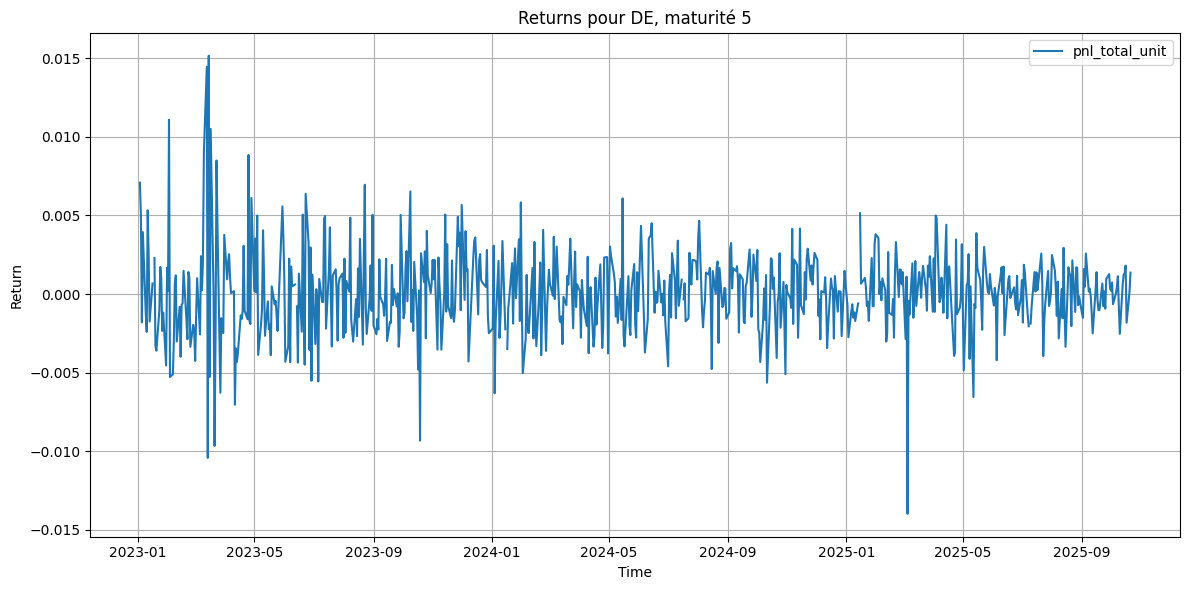

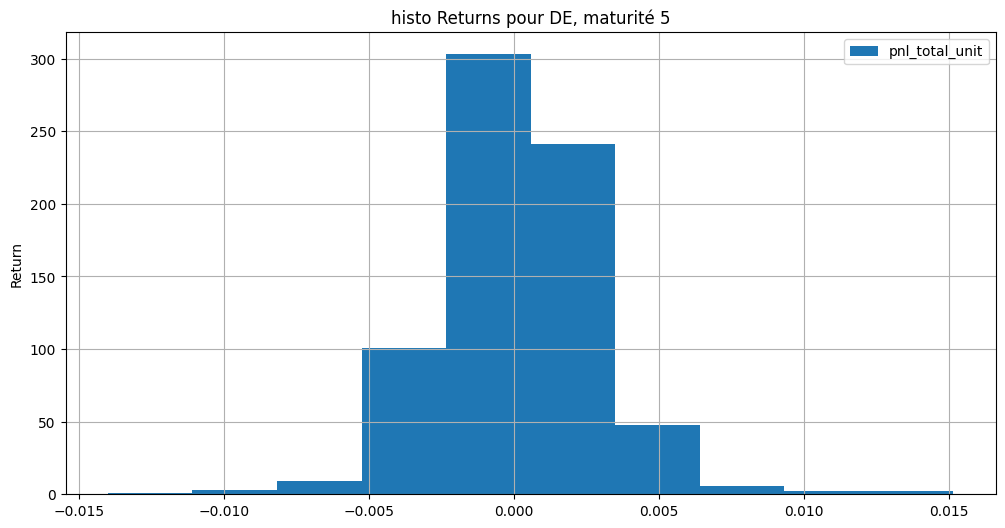

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "ret_total_per_dv01"   # Colonne de return DV01
return_col2 = "pnl_total_unit" # Colonne de coupon quotidien
return_col3 = "pnl_total_unit"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="-")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(df_plot[return_col2], label=return_col2)
plt.title(f"histo Returns pour {country}, maturité {maturity}")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
#On met data sous le bon format. Ce qu'on veut c'est :
# Date | Finacial product (ex FR_5 pour France bond mat 5) | Return
val1 = "ret_total_per_dv01"
val2 = "pnl_total_unit"

data_completed = data[["time_stamp", "country_iso", "mat_cat", val1, val2, "dv01"]].copy()
data_completed["product"] = data_completed["country_iso"].astype(str) + "_" + data_completed["mat_cat"].astype(str)
data_completed = data_completed.drop(columns=["country_iso", "mat_cat"])
data_completed["time_stamp"] = pd.to_datetime(data_completed["time_stamp"])
dv01_ref = data_completed["dv01"].median()
data_completed.head()




,time_stamp,ret_total_per_dv01,pnl_total_unit,dv01,product
0,2015-01-01,NaN,NaN,0.000957,DE_10
1,2015-01-02,4.371456,0.004203,0.000962,DE_10
2,2015-01-05,-1.977655,-0.001896,0.000959,DE_10
3,2015-01-06,7.169240,0.006923,0.000966,DE_10
4,2015-01-07,-3.829079,-0.003681,0.000961,DE_10


## Chargement des bid-offer par bond

In [11]:
bo = pd.read_csv("data/bid_offer_CS.csv")  # adapte le nom si besoin
# Harmonise les types
bo["mat_cat"] = bo["mat_cat"].astype(str)

# On définit le product bond simple : "FR_5", "DE_10", etc.
bo["product"] = bo["country_iso"].astype(str) + "_" + bo["mat_cat"].astype(str)

# On agrège par product (médiane par ex. s'il y a plusieurs ISIN dans le bucket)
bond_bidoffer_yield = (
    bo.groupby("product")["q25_spread_yield"]
    .median()
    .rename("bidoffer_yield_bond")
)
bond_bidoffer_yield_bp = bond_bidoffer_yield 
bond_bidoffer_yield.head()

product
AT_10    0.006
AT_15    0.011
AT_2     0.023
AT_20    0.008
AT_3     0.017
Name: bidoffer_yield_bond, dtype: float64

# Ajout spread et curve 

In [12]:
def add_spread_curve(
    data,
    value_col="pnl_total_unit",
    bond_bidoffer_yield=None
):
    """
    Ajoute au format long (time_stamp, product, value_col) :
      - Obligations "outright" : FR_2, DE_10, ...
      - Spreads entre pays à même maturité      : FR_DE_2        (type = spread_country)
      - Curve Spreads intra-pays                : FR_2_5         (type = spread_curve)
      - Butterflies intra-pays                  : FR_fly_2_5_10  (type = butterfly_curve)
      - Box / Différences de pente entre pays   : FR_DE_slope_2_10 (type = slope_diff_country)

    Paramètres
    ----------
    data : DataFrame
        Colonnes attendues : time_stamp, product, value_col
    value_col : str
        Nom de la colonne de return à utiliser
        (ex: "pnl_total_unit" ou "ret_total_per_dv01")
    bond_bidoffer_yield : Series optionnelle
        index = product (ex: "FR_2"), valeurs = bid/offer en yield pour les bonds simples.

    Retour
    ------
    DataFrame long enrichi avec une colonne 'type'
    et 'bid_offer_yield' si disponible.
    """

    df = data.copy()

    # --- Produits originaux ---
    product_type = {p: "bond" for p in df["product"].unique()}

    # --- Extraction pays / maturités ---
    products = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})

    def sort_mats(mats):
        try:
            return sorted(mats, key=lambda x: float(x))
        except ValueError:
            return sorted(mats)

    maturities = sort_mats({p.split("_")[1] for p in products})

    # --- Pivot large ---
    wide = (
        df
        .pivot(index="time_stamp", columns="product", values=value_col)
        .sort_index()
    )

    # --- Bid / offer par produit ---
    bidoffer_product = {}
    if bond_bidoffer_yield is not None:
        for p in wide.columns:
            if p in bond_bidoffer_yield.index:
                bidoffer_product[p] = bond_bidoffer_yield.loc[p]

    # ============================
    # 1) SPREADS ENTRE PAYS
    # ============================
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]

        for i in range(len(prods_mat)):
            for j in range(i + 1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]

                spread_name = f"{c1}_{c2}_{mat}"
                if spread_name not in wide.columns:
                    wide[spread_name] = wide[p1] - wide[p2]
                    product_type[spread_name] = "spread_country"

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2):
                            half_sum = 0.5 * (bo1 + bo2)
                            bidoffer_product[spread_name] = (
                                half_sum * bid_offer_multiplier["spread"]
                            )

    # ============================
    # 2) SPREADS DE COURBE
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c)):
            for j in range(i + 1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"

                if p1 in wide.columns and p2 in wide.columns:
                    spread_name = f"{c}_{m1}_{m2}"
                    if spread_name not in wide.columns:
                        wide[spread_name] = wide[p1] - wide[p2]
                        product_type[spread_name] = "spread_curve"

                        if bond_bidoffer_yield is not None:
                            bo1 = bidoffer_product.get(p1, np.nan)
                            bo2 = bidoffer_product.get(p2, np.nan)
                            if np.isfinite(bo1) and np.isfinite(bo2):
                                half_sum = 0.5 * (bo1 + bo2)
                                bidoffer_product[spread_name] = (
                                    half_sum * bid_offer_multiplier["curve"]
                                )

    # ============================
    # 3) BUTTERFLIES
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c) - 2):
            m1, m2, m3 = mats_c[i], mats_c[i + 1], mats_c[i + 2]
            p1, p2, p3 = f"{c}_{m1}", f"{c}_{m2}", f"{c}_{m3}"

            if all(p in wide.columns for p in (p1, p2, p3)):
                fly_name = f"{c}_fly_{m1}_{m2}_{m3}"
                if fly_name not in wide.columns:
                    wide[fly_name] = wide[p1] - 2 * wide[p2] + wide[p3]
                    product_type[fly_name] = "butterfly_curve"

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        bo3 = bidoffer_product.get(p3, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2) and np.isfinite(bo3):
                            half_sum = 0.5 * (bo1 + bo2 + bo3)
                            bidoffer_product[fly_name] = (
                                half_sum * bid_offer_multiplier["fly"]
                            )

    # ============================
    # 4) BOX / SLOPE DIFF
    # ============================
    for idx_low in range(len(maturities) - 1):
        for idx_high in range(idx_low + 1, len(maturities)):
            m_low, m_high = maturities[idx_low], maturities[idx_high]

            for i in range(len(countries)):
                for j in range(i + 1, len(countries)):
                    c1, c2 = countries[i], countries[j]
                    p1_low, p1_high = f"{c1}_{m_low}", f"{c1}_{m_high}"
                    p2_low, p2_high = f"{c2}_{m_low}", f"{c2}_{m_high}"

                    if all(p in wide.columns for p in (p1_low, p1_high, p2_low, p2_high)):
                        slope_name = f"{c1}_{c2}_slope_{m_low}_{m_high}"
                        if slope_name not in wide.columns:
                            wide[slope_name] = (
                                (wide[p1_high] - wide[p1_low]) -
                                (wide[p2_high] - wide[p2_low])
                            )
                            product_type[slope_name] = "slope_diff_country"

                            if bond_bidoffer_yield is not None:
                                bo1_low  = bidoffer_product.get(p1_low,  np.nan)
                                bo1_high = bidoffer_product.get(p1_high, np.nan)
                                bo2_low  = bidoffer_product.get(p2_low,  np.nan)
                                bo2_high = bidoffer_product.get(p2_high, np.nan)

                                if all(np.isfinite(x) for x in [bo1_low, bo1_high, bo2_low, bo2_high]):
                                    half_sum = 0.5 * (bo1_low + bo1_high + bo2_low + bo2_high)
                                    bidoffer_product[slope_name] = (
                                        half_sum * bid_offer_multiplier["box"]
                                    )

    # ============================
    # Retour format long
    # ============================
    long = wide.reset_index().melt(
        id_vars="time_stamp",
        var_name="product",
        value_name=value_col
    )

    long["type"] = long["product"].map(product_type).fillna("unknown")

    if bond_bidoffer_yield is not None:
        bo_series = pd.Series(bidoffer_product)
        long["bid_offer_yield"] = long["product"].map(bo_series)

    return long


In [13]:
bid_offer_multiplier = {
    "fly": 0.25,
    "box": 0.375,
    "spread": 0.5,
    "curve": 0.4,
}

long = add_spread_curve(data_completed,value_col="pnl_total_unit",  bond_bidoffer_yield=bond_bidoffer_yield_bp)
long2 = add_spread_curve(data_completed,value_col="ret_total_per_dv01",  bond_bidoffer_yield=bond_bidoffer_yield_bp)
long_dv01 = add_spread_curve(data_completed, value_col="dv01", bond_bidoffer_yield=None)
dv01_by_product = long_dv01.groupby("product")["dv01"].median()

long["ret_total_per_dv01"] = long2["ret_total_per_dv01"]
long.head(10)

long[long["type"].isin(["bond", "spread_country", "spread_curve", "butterfly_curve", "slope_diff_country"])] \
    .groupby("type")["bid_offer_yield"].describe()


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
bond,34920.0,0.008533,0.005476,0.002000,0.004000,0.006000,0.014000,0.020000
butterfly_curve,20952.0,0.002792,0.001402,0.001125,0.001875,0.002125,0.003750,0.005375
slope_diff_country,69840.0,0.006400,0.002084,0.002625,0.004875,0.006562,0.008062,0.010313
spread_country,34920.0,0.004267,0.001948,0.001250,0.002250,0.004250,0.006250,0.007250
spread_curve,69840.0,0.003413,0.001760,0.001000,0.001800,0.003000,0.004600,0.007400


In [14]:
long.head()

,time_stamp,product,pnl_total_unit,type,bid_offer_yield,ret_total_per_dv01
0,2015-01-01,DE_10,NaN,bond,0.003,NaN
1,2015-01-02,DE_10,0.004203,bond,0.003,4.371456
2,2015-01-05,DE_10,-0.001896,bond,0.003,-1.977655
3,2015-01-06,DE_10,0.006923,bond,0.003,7.169240
4,2015-01-07,DE_10,-0.003681,bond,0.003,-3.829079


### Adding Roll-Down from Helper file

In [15]:

roll_base = data_roll[["time_stamp", "country_iso", "mat_cat", "roll_ortho_bp"]].copy()
roll_base["time_stamp"] = pd.to_datetime(roll_base["time_stamp"])

# Normalise mat_cat pour matcher les noms de product (ex "2" et pas "2.0")
roll_base["mat_cat"] = (
    pd.to_numeric(roll_base["mat_cat"], errors="coerce")
    .map(lambda x: str(int(x)) if pd.notna(x) and float(x).is_integer() else str(x))
)

# Agrège pour éviter doublons (date, pays, mat)
roll_base = (
    roll_base.groupby(["time_stamp", "country_iso", "mat_cat"], as_index=False)["roll_ortho_bp"]
    .median()
)

# Colonne attendue par add_spread_curve
roll_base["product"] = roll_base["country_iso"].astype(str) + "_" + roll_base["mat_cat"].astype(str)

# 2) Génère roll pour spreads/fly/slope
roll_input = roll_base[["time_stamp", "product", "roll_ortho_bp"]].copy()
long_roll = add_spread_curve(
    roll_input,
    value_col="roll_ortho_bp",
    bond_bidoffer_yield=None
).rename(columns={"roll_ortho_bp": "roll_ortho_bp_prod"})

# 3) Merge dans long
long_new = long.copy()
long_new["time_stamp"] = pd.to_datetime(long_new["time_stamp"])
long_roll["time_stamp"] = pd.to_datetime(long_roll["time_stamp"])

long_new = long_new.merge(
    long_roll[["time_stamp", "product", "roll_ortho_bp_prod"]],
    on=["time_stamp", "product"],
    how="left",
)

long_new["roll_ortho_bp_prod"] = long_new["roll_ortho_bp_prod"].fillna(0.0)

# 4) Nouveau signal
alpha_roll = 0.35
long_new["ret_total_per_dv01"] = long_new["ret_total_per_dv01"] + alpha_roll * long_new["roll_ortho_bp_prod"]


# Class Portfolio à date t 

In [16]:
class Portfolio:
    def __init__(
        self,
        data,
        date,
        benchmark="ew",
        long_only=True,
        lamb=0.1,
        rebalancement='ME',
        span=6,
        initial_weights=None,
        delta=0.1,
        tc_gamma=0.1
        
    ):
        """
        Classe Portfolio : initialise un portefeuille pour optimisation Markowitz
        basé sur des returns DV01-normalisés.

        Paramètres
        ----------
        data : pd.DataFrame
            Historique des produits avec au moins les colonnes :
            'time_stamp', 'product', 'pnl_total_unit', éventuellement 'ret_total_per_dv01'.
        date : datetime-like
            Date de rebalancement / estimation. Seules les données avant cette date sont utilisées.
        benchmark : str, default "ew"
            Nom du benchmark pour comparaison (ex: equal-weighted).
        long_only : bool, default True
            Si True, les poids sont projetés sur le simplexe (pas de short).
        lamb : float, default 1.0
            Paramètre d’aversion au risque λ pour Markowitz : maximise μ'w - λ w'Σw.
        rebalancement : str, default 'ME'
            Fréquence de rebalancement :
            'D' = quotidien, 'W' = hebdomadaire, 'M' = mensuel, 'ME' = fin de mois.
        span : int, default 6
            Demi-vie pour calcul EWMA des retours moyens.
        initial_weights : array-like or None, default None
            Poids initiaux du portefeuille, pour démarrer l’optimisation.
        delta : float, default 0.1
            Paramètre de régularisation / limite de variation de poids.
        tc_gamma : float, default 0.1
            Coefficient de coût de transaction.

        Attributs internes
        ------------------
        self.data : pd.DataFrame
        self.date : pd.Timestamp
        self.benchmark : str
        self.long_only : bool
        self.lamb : float
        self.rebalancement : str
        self.sigma_level : float
        self.span : int
        self.initial_weights : array-like or None
        self.delta : float
        self.tc_gamma : float

        self.returns : pd.DataFrame
            Returns filtrés jusqu'à self.date.
        self.mean_returns : pd.DataFrame or pd.Series
            Moyenne des retours (EWMA).
        self.cov_matrix : pd.DataFrame
            Matrice de covariance des returns.
        self.weights : pd.Series or np.array
            Poids optimisés pour la période courante.
        self.benchmark_weights : pd.Series or np.array
            Poids du benchmark pour comparaison.
        """

        # --- données et date ---
        self.data = data
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark

        # --- paramètres optimisation ---
        self.long_only = long_only
        self.lamb = float(lamb)
        self.rebalancement = rebalancement
        self.span = span
        self.delta = delta
        self.tc_gamma = float(tc_gamma)
        self.initial_weights = initial_weights

        # --- attributs internes ---
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None
        self.benchmark_weights = None

    def get_returns_until(self):
        """Filter returns up to self.date and resample according to rebalancement."""
        R = self.data[self.data["time_stamp"] < self.date].copy()

        # --- resampling selon la fréquence de rebalancement ---
        if hasattr(self, "rebalancement") and self.rebalancement in ["D", "W", "ME"]:
            df_list = []
            for prod, df_prod in R.groupby("product"):
                df_prod = df_prod.set_index("time_stamp").sort_index()
                if self.rebalancement != "D":
                    df_resampled = df_prod["ret_total_per_dv01"].resample(self.rebalancement).sum()
                else:
                    df_resampled = df_prod["ret_total_per_dv01"]
                df_resampled = df_resampled.reset_index()
                df_resampled["product"] = prod
                df_list.append(df_resampled)
            R = pd.concat(df_list, axis=0)
        else:
            # default = daily
            R = R.copy()

        self.returns = R.sort_values(["product", "time_stamp"])


    def estimate_returns(self):
        """EWMA of returns per product, shifted by 1 day to avoid look-ahead."""
        span = self.span

        df = self.returns[["time_stamp", "product", "ret_total_per_dv01"]].copy()
        df = df.sort_values(["product", "time_stamp"])

        df["ret_total_per_dv01"] = (
            df.groupby("product")["ret_total_per_dv01"].shift(1)
        )

        ewma = (
            df.groupby("product")["ret_total_per_dv01"]
            .apply(lambda x: x.ewm(span=span, adjust=False).mean().iloc[-1])
            .reset_index(name="ewma_ret_dv01")
        )

        self.mean_returns = ewma

    def estimate_cov_matrix_Ledoit(self):
        """
        Estimate covariance matrix using Ledoit-Wolf shrinkage.
        Only uses dates where ALL products have data (complete-case analysis).
        """
        panel = self.returns.pivot(
            index="time_stamp",
            columns="product",
            values="ret_total_per_dv01",
        ).sort_index()

        # --- Drop dates with any missing product ---
        panel_clean = panel.dropna(axis=0, how="any")

        if len(panel_clean) < 2:
            # Fallback: not enough overlapping data → diagonal matrix
            import warnings
            warnings.warn(
                f"Only {len(panel_clean)} overlapping dates for covariance at {self.date}. "
                "Using diagonal (variance-only) estimate."
            )
            # Use per-column variance (ignoring NaN) as diagonal
            var = panel.var(skipna=True).fillna(0.0).values
            n = panel.shape[1]
            cov_matrix = np.diag(var)
        else:
            X = panel_clean.values
            lw = LedoitWolf().fit(X)
            cov_matrix = lw.covariance_

        self.cov_matrix = pd.DataFrame(
            cov_matrix,
            columns=panel.columns,
            index=panel.columns,
        )

    def estimate_cov_matrix_factor(self, halflife=63, shrinkage=0.2):
        """
        Factor risk model: country × maturity factors + market factor.
        Σ = B @ F @ B.T + D

        Uses EWMA covariance (time-varying) instead of full-sample Ledoit-Wolf.

        Parameters
        ----------
        halflife : int
            EWMA half-life in days for factor covariance (default 63 ≈ 3 months).
        shrinkage : float
            Shrinkage intensity toward diagonal (0 = sample, 1 = diagonal).
        """

        panel = self.returns.pivot(
            index="time_stamp", columns="product", values="ret_total_per_dv01"
        ).sort_index()
        products = list(panel.columns)
        n_products = len(products)

        # ---- 1) Identify base bonds (factors) ----
        base_pattern = re.compile(r'^([A-Z]{2})_(\d+)$')
        base_bonds = [p for p in products if base_pattern.match(p)]

        if len(base_bonds) < 2:
            import warnings
            warnings.warn("Cannot identify base bonds, falling back to Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()

        factor_idx = {b: i for i, b in enumerate(base_bonds)}
        n_base = len(base_bonds)
        # Total factors = base bonds + 1 market factor
        n_factors = n_base + 1
        market_col = n_base  # last column is market factor

        # ---- 2) Build loading matrix B (n_products × n_factors) ----
        B = np.zeros((n_products, n_factors))

        country_weights = {"DE": 0.30, "FR": 0.25, "IT": 0.25, "SP": 0.20}

        for i, prod in enumerate(products):
            parts = prod.split("_")

            # Bond: "DE_10" → +1 on DE_10
            if base_pattern.match(prod):
                B[i, factor_idx[prod]] = 1.0
                # Also loads on market factor
                country = parts[0]
                B[i, market_col] = country_weights.get(country, 0.25)

            # Butterfly: "DE_fly_2_5_10" → +1, -2, +1
            elif "fly" in parts:
                fly_pos = parts.index("fly")
                country = parts[0]
                mats = parts[fly_pos + 1:]
                if len(mats) == 3:
                    keys = [f"{country}_{m}" for m in mats]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] = 1.0
                        B[i, factor_idx[keys[1]]] = -2.0
                        B[i, factor_idx[keys[2]]] = 1.0
                        # Butterfly is market-neutral → no market loading

            # Nesterov butterfly: "DE_Ny_2_5_10"
            elif "Ny" in parts:
                ny_pos = parts.index("Ny")
                country = parts[0]
                mats = parts[ny_pos + 1:]
                if len(mats) == 3:
                    keys = [f"{country}_{m}" for m in mats]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] = 1.0
                        B[i, factor_idx[keys[1]]] = -2.0
                        B[i, factor_idx[keys[2]]] = 1.0

            # Slope diff: "FR_DE_slope_2_10"
            elif "slope" in parts:
                slope_pos = parts.index("slope")
                c1, c2 = parts[0], parts[1]
                mats = parts[slope_pos + 1:]
                if len(mats) == 2:
                    m_low, m_high = mats
                    keys = [f"{c1}_{m_low}", f"{c1}_{m_high}", f"{c2}_{m_low}", f"{c2}_{m_high}"]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] = -1.0
                        B[i, factor_idx[keys[1]]] = 1.0
                        B[i, factor_idx[keys[2]]] = 1.0
                        B[i, factor_idx[keys[3]]] = -1.0

            # Country spread: "FR_DE_2" → +1 FR_2, -1 DE_2
            elif len(parts) == 3 and all(len(p) == 2 and p.isalpha() for p in parts[:2]):
                c1, c2, mat = parts
                p1, p2 = f"{c1}_{mat}", f"{c2}_{mat}"
                if p1 in factor_idx and p2 in factor_idx:
                    B[i, factor_idx[p1]] = 1.0
                    B[i, factor_idx[p2]] = -1.0
                    # Partial market loading (country diff)
                    w1 = country_weights.get(c1, 0.25)
                    w2 = country_weights.get(c2, 0.25)
                    B[i, market_col] = w1 - w2

            # Curve spread: "DE_2_10" → +1 DE_2, -1 DE_10
            elif len(parts) == 3 and len(parts[0]) == 2 and parts[0].isalpha():
                country, m1, m2 = parts
                p1, p2 = f"{country}_{m1}", f"{country}_{m2}"
                if p1 in factor_idx and p2 in factor_idx:
                    B[i, factor_idx[p1]] = 1.0
                    B[i, factor_idx[p2]] = -1.0
                    # Curve spread is duration-neutral → no market loading

        # ---- 3) Build factor return series (including market) ----
        factor_returns_raw = panel[base_bonds].copy()
        factor_returns_clean = factor_returns_raw.dropna(how="any")

        if len(factor_returns_clean) < n_base + 1:
            import warnings
            warnings.warn("Not enough data for factor model, falling back to Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()

        # Market factor: weighted average of base bond returns
        market_return = pd.Series(0.0, index=factor_returns_clean.index)
        total_w = 0
        for bond in base_bonds:
            country = bond.split("_")[0]
            w = country_weights.get(country, 0.25)
            market_return += w * factor_returns_clean[bond]
            total_w += w
        market_return /= total_w

        # Combine: base bonds + market
        factor_matrix = factor_returns_clean.copy()
        factor_matrix["_MARKET_"] = market_return
        factor_vals = factor_matrix.values  # (T × n_factors)
        T = factor_vals.shape[0]

        # ---- 4) EWMA factor covariance ----
        ewma_weights = np.exp(-np.log(2) / halflife * np.arange(T)[::-1])
        ewma_weights /= ewma_weights.sum()

        mu = (ewma_weights[:, None] * factor_vals).sum(axis=0)
        centered = factor_vals - mu
        F = (centered * ewma_weights[:, None]).T @ centered

        # Shrink toward diagonal
        diag_F = np.diag(np.diag(F))
        F = (1 - shrinkage) * F + shrinkage * diag_F

        # Symmetrize
        F = 0.5 * (F + F.T)
        F += 1e-10 * np.eye(n_factors)

        # ---- 5) Product covariance: Σ = B @ F @ B.T + D ----
        Sigma_factor = B @ F @ B.T

        # ---- 6) EWMA idiosyncratic variance ----
        # Predicted returns from factor model
        factor_panel_full = panel[base_bonds].fillna(0).copy()
        factor_panel_full["_MARKET_"] = 0.0
        for bond in base_bonds:
            country = bond.split("_")[0]
            w = country_weights.get(country, 0.25)
            factor_panel_full["_MARKET_"] += w * panel[base_bonds].fillna(0)[bond]
        factor_panel_full["_MARKET_"] /= total_w

        predicted = factor_panel_full.values @ B.T  # (T_full × n_products)
        actual = panel[products].fillna(0).values
        residuals = actual - predicted

        T_full = residuals.shape[0]
        ewma_w_full = np.exp(-np.log(2) / halflife * np.arange(T_full)[::-1])
        ewma_w_full /= ewma_w_full.sum()
        d = (ewma_w_full[:, None] * residuals**2).sum(axis=0)
        d = np.maximum(d, 1e-10)
        D = np.diag(d)

        Sigma = Sigma_factor + D

        # Final regularization
        Sigma = 0.5 * (Sigma + Sigma.T)
        Sigma += 1e-8 * np.eye(n_products)

        self.cov_matrix = pd.DataFrame(Sigma, columns=products, index=products)


    def markowitz2_qp(self):
        """
        Version QP de Markowitz avec coûts de transaction linéaires en turnover.
        """

        # 1) μ et Σ
        mean = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean = mean.reindex(self.cov_matrix.index).fillna(0.0)
        mean_returns = mean.values

        Sigma = self.cov_matrix.values
        n = len(mean_returns)
        lambda_risk = self.lamb
        gamma_tc = self.tc_gamma
        long_only = self.long_only

        # --- PATCH NUMERIQUE SUR Σ ---
        Sigma = 0.5 * (Sigma + Sigma.T)         # symétrisation
        Sigma = Sigma + 1e-8 * np.eye(n)        # régularisation diagonale

        # 2) w_prev aligné
        if self.initial_weights is None:
            if long_only:
                w_prev = np.ones(n) / n
            else:
                w_prev = np.zeros(n)
        else:
            if isinstance(self.initial_weights, pd.Series):
                w_prev_series = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            elif isinstance(self.initial_weights, pd.DataFrame):
                w_prev_series = self.initial_weights.iloc[:, 0]
                w_prev_series = w_prev_series.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            else:
                w_prev = np.asarray(self.initial_weights, dtype=float)
                if w_prev.shape[0] != n:
                    raise ValueError("initial_weights non compatible avec la dimension de la covariance.")

        # Si market-neutral, recentre w_prev
        if not long_only:
            w_prev = w_prev - w_prev.mean()

        # 3) c_vec depuis bid_offer_yield
        if "bid_offer_yield" in self.data.columns:
            bo = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
            )
            c_vec = bo.values
        else:
            c_vec = np.zeros(n)

        # 4) Variables
        w = cp.Variable(n)
        t = cp.Variable(n)

        # 5) Bornes dynamiques
        if long_only:
            w_min = np.zeros(n)
            w_max = w_prev + self.delta
        else:
            w_min = w_prev - self.delta
            w_max = w_prev + self.delta

        # 6) Contraintes
        target_sum = 1.0 if long_only else 0.0
        constraints = [
            cp.sum(w) == target_sum,
            w >= w_min,
            w <= w_max,
            t >= w - w_prev,
            t >= -(w - w_prev),
            t >= 0
        ]

        # 7) Objectif
        quad_term = lambda_risk * cp.quad_form(w, cp.psd_wrap(Sigma))
        mean_term = - mean_returns @ w
        if gamma_tc > 0 and np.any(c_vec != 0):
            tc_term = gamma_tc * (c_vec @ t)
        else:
            tc_term = 0

        objective = cp.Minimize(quad_term + mean_term + tc_term)

        # 8) Résolution
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP, verbose=False)
        except Exception:
            prob.solve(solver=cp.SCS, verbose=False)

        if w.value is None:
            raise ValueError("Optimisation QP échouée : statut = " + prob.status)

        w_opt = np.array(w.value).flatten()

        # 9) Nettoyage
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0

        if long_only:
            s = w_opt.sum()
            if s != 0:
                w_opt = w_opt / s
        else:
            gross = np.sum(np.abs(w_opt))
            if gross > 0:
                w_opt = w_opt / gross

        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights




    def markowitz2(self):

        # ---- 1) Vecteur de rendements attendus ----
        mean = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean = mean.reindex(self.cov_matrix.index).fillna(0.0)
        mean_returns = mean.values

        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)
        lambda_risk = self.lamb
        long_only = self.long_only
        gamma_tc = getattr(self, "tc_gamma", 0.0)
        eps_tc = 1e-8  # pour lisser |x| ≈ sqrt(x^2 + eps)

        # ---- 2) Poids précédents (w_prev), correctement alignés ----
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        else:
            if isinstance(self.initial_weights, pd.Series):
                w_prev_series = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            elif isinstance(self.initial_weights, pd.DataFrame):
                # on prend la première colonne si DataFrame
                w_prev_series = self.initial_weights.iloc[:, 0]
                w_prev_series = w_prev_series.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            else:
                # numpy array ou liste
                w_prev = np.asarray(self.initial_weights, dtype=float)
                if w_prev.shape[0] != n:
                    raise ValueError("initial_weights non compatible avec la dimension de la covariance.")

        # ---- 3) Coefficients de coût c_i à partir des bid_offer_yield ----
        if ("bid_offer_yield" in self.data.columns):
            # médiane sur l’historique pour chaque product
            bo = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
            )
            c_vec = bo.values
        else:
            c_vec = np.zeros(n)

        # ---- 4) Fonction objectif avec coûts de transaction ----
        def objective(w):
            # risque
            risk_term = lambda_risk * (w @ cov_matrix @ w)
            # rendement
            mean_term = - (w @ mean_returns)
            # coût de transaction
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                tc_term = gamma_tc * np.sum(c_vec * np.sqrt(diff * diff + eps_tc))
            else:
                tc_term = 0.0
            return risk_term + mean_term + tc_term

        # ---- 5) Gradient de l’objectif ----
        def grad_objective(w):
            # dérivée risk
            grad_risk = 2.0 * lambda_risk * (cov_matrix @ w)
            # dérivée rendement
            grad_mean = -mean_returns
            # dérivée coût de transaction
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                denom = np.sqrt(diff * diff + eps_tc)
                grad_tc = gamma_tc * c_vec * (diff / denom)
            else:
                grad_tc = np.zeros_like(w)
            return grad_risk + grad_mean + grad_tc

        # ---- 6) Contraintes et bornes ----
        constraints = [
            {'type': 'eq',
            'fun': lambda w: np.sum(w) - 1.0,
            'jac': lambda w: np.ones_like(w)}
        ]

        # Bornes dynamiques (comme ta V2)
        bounds = []
        if long_only:
            for wp in w_prev:
                # poids min 0, max wp + delta
                bounds.append((max(0,wp - self.delta), wp + self.delta))
        else:
            for wp in w_prev:
                bounds.append((wp - self.delta, wp + self.delta))


        # ---- 7) Initialisation ----
        w0 = np.clip(w_prev, [b[0] for b in bounds], [b[1] for b in bounds])
        if w0.sum() == 0:
            w0 = np.ones(n) / n
        else:
            w0 = w0 / w0.sum()



        # ---- 9) Nettoyage / normalisation ----
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0
        if w_opt.sum() != 0:
            w_opt = w_opt / w_opt.sum()

        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights

    def markowitz_robust(self):
        """
        Markowitz optimization with turnover control and transaction cost penalty.

        Objective:  min  λ · w'Σw  −  w'μ  +  γ · Σᵢ cᵢ √((wᵢ − wᵢᵖʳᵉᵛ)² + ε)
        Subject to: Σ wᵢ = 1
                    wᵢ ∈ [wᵢᵖʳᵉᵛ − δ, wᵢᵖʳᵉᵛ + δ]   (turnover bounds)
                    wᵢ ≥ 0  if long_only

        The smoothed absolute value √(x² + ε) avoids non-differentiability at x=0.
        """
        # ---- 1) Expected returns and covariance ----
        mean_returns = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean_returns = mean_returns.reindex(self.cov_matrix.index).fillna(0.0).values
        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)

        # ---- 2) Previous weights (properly typed) ----
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        elif isinstance(self.initial_weights, pd.Series):
            w_prev = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0).values
        elif isinstance(self.initial_weights, pd.DataFrame):
            w_prev = self.initial_weights.iloc[:, 0].reindex(self.cov_matrix.index).fillna(0.0).values
        else:
            w_prev = np.asarray(self.initial_weights, dtype=float)
            if w_prev.shape[0] != n:
                raise ValueError(
                    f"initial_weights length {w_prev.shape[0]} != covariance dimension {n}"
                )

        # ---- 3) Transaction cost vector ----
        if "bid_offer_yield" in self.data.columns:
            c_vec = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
                .values
            )
        else:
            c_vec = np.zeros(n)

        lambda_risk = self.lamb
        gamma_tc = self.tc_gamma
        eps_tc = 1e-8
        n = len(w_prev)

        # ---- Pré-calcul des normalisations (NE DEPEND PAS DE w) ----
        w_ref = np.ones(n) / n

        scale_risk = w_ref @ cov_matrix @ w_ref
        scale_risk = max(scale_risk, 1e-12)

        scale_mean = abs(w_ref @ mean_returns)
        scale_mean = max(scale_mean, 1e-12)

        if gamma_tc > 0.0 and np.any(c_vec != 0):
            diff_ref = w_ref - w_prev
            scale_tc = np.sum(c_vec * np.sqrt(diff_ref**2 + eps_tc))
            scale_tc = max(scale_tc, 1e-12)
        else:
            scale_tc = 1.0  # neutre si pas utilisé

        
        # ---- 4) Objective: risk − return + TC penalty ----
        def objective(w):

            # --- Risk term ---
            risk_raw = w @ cov_matrix @ w
            risk_term = lambda_risk * risk_raw / scale_risk

            # --- Mean term ---
            mean_raw = w @ mean_returns
            mean_term = - mean_raw / scale_mean

            # --- Transaction cost term ---
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                tc_raw = np.sum(c_vec * np.sqrt(diff**2 + eps_tc))
                tc_term = gamma_tc * tc_raw / scale_tc
            else:
                tc_term = 0.0

            # ---- PRINTS (temporaire analyse) ----
            #print("risk:", risk_term)
            #print("mean:", mean_term)
            #print("tc:", tc_term)

            return risk_term + mean_term + tc_term


        # ---- 5) Gradient ----
        def grad_objective(w):

            # --- Risk gradient ---
            grad_risk = 2.0 * lambda_risk * (cov_matrix @ w) / scale_risk

            # --- Mean gradient ---
            grad_mean = - mean_returns / scale_mean

            # --- Transaction cost gradient ---
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                grad_tc = gamma_tc * c_vec * (diff / np.sqrt(diff**2 + eps_tc)) / scale_tc
            else:
                grad_tc = np.zeros_like(w)

            # ---- PRINTS (temporaire analyse) ----
            #print("grad risk max:", np.max(np.abs(grad_risk)))
            #print("grad mean max:", np.max(np.abs(grad_mean)))
            #print("grad tc max:", np.max(np.abs(grad_tc)))

            return grad_risk + grad_mean + grad_tc
        

        # ---- 6) Contraintes ---- 
        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0, 'jac': lambda w: np.ones_like(w)}] 
        
        # ---- 7) Bornes ---- 
        bounds = [] 
        if self.long_only:
            for wp in w_prev:
                bounds.append((max(0, wp-0.2), min(1, wp+0.2))) 
        else: 
            for wp in w_prev:
                bounds.append((max(-1, wp-0.2), min(1, wp+0.2))) 
        # ---- 8) Initialisation ---- 
        w0 = np.clip(w_prev, [b[0] for b in bounds], [b[1] for b in bounds]) 
        if w0.sum() == 0:
            w0 = np.ones(n) / n 
        else:
            w0 = w0 / w0.sum() 
            
        # ---- 9) Optimisation ---- 

        res = minimize( objective, w0, jac=grad_objective, constraints=constraints,
                        bounds=bounds, method='SLSQP',
                          options={'ftol': 1e-9, 'disp': False, 'maxiter': 1000} )        
   
        if not res.success:
            # Au lieu de lever une exception, on reprend les poids précédents
            print(f"Optimisation échouée à {self.date}, on reprend les poids précédents")
            w_opt = w_prev.copy()
        else:
            w_opt = res.x
        
        # ---- 11) Cleanup: zero out tiny weights and renormalize ----
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0
        w_sum = w_opt.sum()
        if w_sum != 0:
            w_opt = w_opt / w_sum

        # ---- 12) Return ----
        self.weights = pd.DataFrame(
            w_opt,
            index=self.cov_matrix.index,
            columns=[self.date],
        )
        return self.weights




    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(n) / n,index=self.mean_returns["product"], columns=[self.date])
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented for now.")

    def process(self, use_qp=False):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix_factor()

        """        
        if use_qp:
            self.markowitz2_qp()
        else:
            self.markowitz2()   # ta version SLSQP existante
        """
        self.markowitz_robust()
        self.benchmark_w()
        return self.weights



In [17]:
date = "2021-06-01"


pf = Portfolio(long, date, benchmark="ew", long_only=True,lamb=0.5, tc_gamma=10 )
#print(pf.returns)
w = pf.process() 
#print(pf.mean_returns)
print(w)

                 2021-06-01
DE_10              0.010087
DE_10_15           0.010105
DE_10_30           0.010110
DE_15              0.010093
DE_15_30           0.010102
...                     ...
IT_5_15            0.010125
IT_5_30            0.010137
IT_fly_10_15_30    0.010098
IT_fly_2_5_10      0.010079
IT_fly_5_10_15     0.010112

[99 rows x 1 columns]


# Creation du time series portfolio

In [18]:
class TimeSeriesPortfolio:
    def __init__(self, data, start_date, end_date, rebalance_freq='ME',
                 long_only=False, lamb=1, benchmark="ew", 
                capital_init=100_000, span = 6, initial_weights= None, delta = 0.1, tc_gamma=1, use_qp=False):

        # Convert time_stamp to Timestamp
        self.data = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = float(lamb)
        self.benchmark = benchmark
        self.capital_init = capital_init
        self.span = span
        
        self.tc_gamma = float(tc_gamma)
        self.delta = delta
        self.initial_weights = initial_weights
        
        # Univers global d'actifs (tous les products jamais vus dans self.data)
        self.asset_universe = sorted(self.data["product"].unique())
        
        self.countries = sorted({p.split("_")[0] for p in self.asset_universe})

        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}

        # *** Séries de bid-offer par produit (en yield), agrégées sur le temps
        if "bid_offer_yield" in self.data.columns:
            # médiane sur l'historique, par product
            self.bidoffer_by_product = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .rename("bid_offer_yield")
            )
        else:
            # pas d'info => 0
            self.bidoffer_by_product = pd.Series(0.0, index=self.asset_universe)

        # Filter data for rolling window
        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f == 'ME':
            return f
        if f.endswith(('D', 'B', 'W')):
            return f
        return 'ME'

    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(start=self.start_date, end=self.end_date,
                                freq=self.freq_to_pd_freq())
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)  # assure tz-naive Timestamp
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list = []
        exposures_list = []

        pf_rel_returns = []
        bm_rel_returns= []
        returns_dates = []

        pf_pnl_daily = []
        bm_pnl_daily = []

        # *** tracking des coûts de transaction
        tc_dates = []
        tc_values = []

        capital = self.capital_init
        current_value = capital
        current_value_bm = capital
        w = self.initial_weights

        # *** expositions précédentes (pour calculer les deltas)
        prev_exposure_full = pd.Series(0.0, index=self.asset_universe)

        # *** vecteur de bid-offer aligné sur l'univers global
        bo_full = self.bidoffer_by_product.reindex(self.asset_universe).fillna(0.0)

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]
            
            pf = Portfolio(
                data=self.data,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                span=self.span,
                initial_weights=w,
                delta=self.delta,
                tc_gamma=self.tc_gamma 
            )
            
            w_df = pf.process()

            w = w_df.iloc[:, 0]  # Series: index = produits présents dans Σ à cette date

            # 1) Reindexer les poids sur l'univers global, en mettant 0 où l'actif n'est pas dans Σ
            w_full = w.reindex(self.asset_universe).fillna(0.0)

            # Benchmark
            w_bm = pf.benchmark_weights.reindex(self.asset_universe).iloc[:, 0].fillna(0.0)

            # 2) Normalisation des expositions 
            target_dv01 = self.capital_init * dv01_ref 
            denom_pf = np.sum(np.abs(w_full.values))
            if denom_pf > 0:
                exposure_full = w_full * (target_dv01 / denom_pf)
            else:
                exposure_full = w_full.copy()

            denom_bm = np.sum(np.abs(w_bm.values))
            if denom_bm > 0:
                exposure_bm_full = w_bm * (target_dv01 / denom_bm)
            else:
                exposure_bm_full = w_bm.copy()

            # *** 2bis) Coût de transaction du rebalance (en PnL)
            # delta d'exposition (nouveau - ancien) sur chaque produit
            delta_exposure_full = exposure_full - prev_exposure_full

            # coût total = somme |delta_expo| * bid_offer_yield_effectif
            # (bid_offer_yield est déjà une "demi-spread" efficace par ton design)
            #tc_total = np.sum(np.abs(delta_exposure_full.values) * bo_full.values)
            # dv01 par produit (bp price impact)
            dv01_full = self.dv01_by_product.reindex(self.asset_universe).fillna(0.0).values

            # bid/offer en bp (q25_spread_yield est en décimal -> *1e4)
            bo_bp = bo_full.values * 100

            tc_total = np.sum(np.abs(delta_exposure_full.values) * bo_bp)

            # on met à jour les expositions précédentes
            prev_exposure_full = exposure_full.copy()

            # 3) Slice des PnL unitaires pour la période (t, t_next]
            period_mask = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            R_slice = R_slice_long.pivot(
                index="time_stamp",
                columns="product",
                values="ret_total_per_dv01"
            )

            # On garde uniquement les colonnes de l’univers global (intersection)
            common_cols = [p for p in self.asset_universe if p in R_slice.columns]
            R_slice = R_slice[common_cols].fillna(0.0)

            # 4) Aligner les expositions sur ces colonnes
            exp_pf = exposure_full.reindex(common_cols).values
            exp_bm = exposure_bm_full.reindex(common_cols).values

            # 5) PnL par jour (mid-market)
            pf_pnl_day = R_slice.values @ exp_pf
            bm_pnl_day = R_slice.values @ exp_bm

            # *** Intégration du coût de transaction au PnL du portefeuille
            if len(pf_pnl_day) > 0:
                # on impute le coût le jour du rebalance (premier jour de la période)
                pf_pnl_day[0] -= tc_total
                tc_dates.append(R_slice.index[0])
            else:
                # cas rare où il n'y aurait pas de date entre t et t_next :
                # on enregistre le coût à la date de rebalance t
                tc_dates.append(t)
                # on ajoute un PnL "artificiel" -tc_total
                pf_pnl_day = np.array([-tc_total])
                bm_pnl_day = np.array([0.0])
                # on ajoute aussi une pseudo-date
                R_slice = pd.DataFrame(
                    index=[t],
                    data=np.zeros((1, len(common_cols))),
                    columns=common_cols
                )

            tc_values.append(tc_total)

            pf_pnl_daily.extend(pf_pnl_day)
            bm_pnl_daily.extend(bm_pnl_day)

            pf_rel_returns.extend((pf_pnl_day / current_value).tolist())
            bm_rel_returns.extend((bm_pnl_day / current_value_bm).tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()

            # 6) Stocker les poids / expositions sur l’univers global
            weights_list.append(w_full.values)
            exposures_list.append(exposure_full.values)

        asset_names = self.asset_universe
        self.weights_history = pd.DataFrame(
            weights_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )
        self.exposures_history = pd.DataFrame(
            exposures_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )


        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_rel_returns, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_rel_returns, index=pd.DatetimeIndex(returns_dates))

        # Cumulative return
        pf_cum_return = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum_return = (1 + self.benchmark_returns.fillna(0)).cumprod()

        # Cumulative PnL
        pf_value = pd.Series(capital + np.array(pf_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        bm_value = pd.Series(capital + np.array(bm_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        pf_pnl = pd.Series(pf_pnl_daily, index=pd.DatetimeIndex(returns_dates))
        bm_pnl = pd.Series(bm_pnl_daily, index=pd.DatetimeIndex(returns_dates))

        trading_days = 252
        pf_mean = self.portfolio_returns.mean()
        pf_std = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std != 0 else np.nan

        # Metrics
        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        # *** série des coûts de transaction
        tc_series = pd.Series(tc_values, index=pd.DatetimeIndex(tc_dates))

        self.metrics = {
            "initial_capital": capital,
            "portfolio_value": pf_value,
            "benchmark_value": bm_value,
            "portfolio_pnl": pf_pnl,
            "benchmark_pnl": bm_pnl,
            "pf_cumulative_return": pf_cum_return,
            "bm_cumulative_return": bm_cum_return,
            "mean_return": pf_mean,
            "volatility": pf_std,
            "sharpe": pf_sharpe,
            "gross_exposure": np.abs(self.exposures_history).sum(axis=1),
            "net_exposure": self.exposures_history.sum(axis=1),
            "drawdown": dd,
            "max_drawdown": dd.min() if len(dd) > 0 else np.nan,
            "transaction_costs": tc_series,     # *** nouvelle entrée
        }

        print("Tout a marché !!")

    
    def _decompose_product_legs(self, product):
        """
        Décompose un product en jambes élémentaires (country, maturity, coef).

        Conventions de nommage gérées :
          - Bond simple           : FR_5
          - Spread pays           : FR_DE_5              -> +FR_5, -DE_5
          - Spread courbe         : FR_2_5 ou FR_10_5    -> +FR_2/10, -FR_5
          - Butterfly intra-pays  : FR_fly_2_5_10        -> +FR_2, -2 FR_5, +FR_10
          - Slope diff pays       : FR_DE_slope_2_10     -> (FR_10 - FR_2) - (DE_10 - DE_2)

        Retourne une liste de tuples (country, maturity, coef).
        """
        parts = product.split("_")

        # Bond simple : "FR_5"
        if len(parts) == 2:
            c, m = parts
            return [(c, m, 1.0)]

        # Cas len(parts) == 3 : soit spread pays FR_DE_5, soit spread courbe FR_2_5 / FR_10_5
        if len(parts) == 3:
            p0, p1, p2 = parts

            # On utilise la vraie liste de pays pour décider
            # 1) Spread pays : FR_DE_5
            if p0 in getattr(self, "countries", []) and p1 in getattr(self, "countries", []):
                c1, c2, mat = p0, p1, p2
                return [(c1, mat,  1.0),
                        (c2, mat, -1.0)]

            # 2) Spread courbe : FR_2_5, FR_10_5, etc.
            if p0 in getattr(self, "countries", []):
                c, m1, m2 = p0, p1, p2
                return [(c, m1,  1.0),
                        (c, m2, -1.0)]

        # Butterfly : FR_fly_2_5_10
        if len(parts) == 5 and parts[1] == "fly":
            c, _, m1, m2, m3 = parts
            return [(c, m1,  1.0),
                    (c, m2, -2.0),
                    (c, m3,  1.0)]

        # Slope diff pays : FR_DE_slope_2_10
        if len(parts) == 5 and parts[2] == "slope":
            c1, c2, _, m_low, m_high = parts
            return [
                (c1, m_high,  1.0),
                (c1, m_low,  -1.0),
                (c2, m_high, -1.0),
                (c2, m_low,   1.0),
            ]

        # Cas non reconnu : on ignore
        return []

    
    def exposition_by_country(self):
        """
        Calcule l'exposition par pays en tenant compte des combinaisons linéaires
        des produits (bonds, spreads, butterflies, slopes).

        Pour chaque produit j et chaque jour t :
        expo_country[c, t] = somme_j ( expo_j(t) * coef_{j,c,*} )
        où coef_{j,c,*} vient de la décomposition en jambes (country, maturity, coef).
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        # Pré-calcul des jambes pour chaque produit
        legs_by_product = {}
        countries = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                countries.add(c)

        if not countries:
            # Aucun produit reconnu -> on renvoie un DF vide mais bien formé
            return pd.DataFrame(index=df.index)

        # DataFrame resultat : dates x pays
        countries = sorted(countries)
        expo_by_country = pd.DataFrame(0.0, index=df.index, columns=countries)

        # Agrégation : pour chaque produit, répartir son expo sur les pays
        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]  # Series index=date

            for c, m, coef in legs:
                expo_by_country[c] += coef * exp_p

        return expo_by_country
    
    def exposition_by_mat(self):
        """
        Calcule l'exposition par maturité (toutes devises confondues) en tenant
        compte des combinaisons linéaires des produits.

        Pour chaque produit j et chaque jour t :
        expo_mat[m, t] = somme_j ( expo_j(t) * coef_{j,*,m} )
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        legs_by_product = {}
        maturities = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                maturities.add(m)

        if not maturities:
            return pd.DataFrame(index=df.index)

        maturities = sorted(maturities, key=lambda x: float(x) if str(x).replace(".", "", 1).isdigit() else x)
        expo_by_mat = pd.DataFrame(0.0, index=df.index, columns=maturities)

        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]

            for c, m, coef in legs:
                expo_by_mat[m] += coef * exp_p

        return expo_by_mat





In [19]:
# === DIAGNOSTIC: Trace bid_offer_yield units ===

# 1) Raw bond bid/offer (before spread construction)
print("=== Raw bond bid_offer_yield ===")
bond_bo = long.groupby("product")["bid_offer_yield"].median()
print(bond_bo.describe())
print()
print("Sample values:")
print(bond_bo.head(10))
print()

# 2) After spread construction (with bid_offer_multiplier applied)
print("=== After add_spread_curve ===")
print(long.groupby("type")["bid_offer_yield"].describe())
print()

# 3) What does the TC actually look like?
# If bid_offer_yield is in yield (e.g., 0.006 = 60bp), 
# then TC = |Δexposure| * 0.006 = 0.6% of turnover notional
# If bid_offer_yield is in bp/100 (e.g., 0.006 = 0.6bp),
# then TC = |Δexposure| * 0.006 = 0.06% of turnover notional

# 4) Sanity check: what is the total TC per rebalance?
print("=== TC budget check ===")
# Assume 100k capital, full turnover, average bo = 0.006
example_turnover = 100_000
avg_bo = bond_bo.mean()
print(f"Average bid_offer_yield: {avg_bo:.6f}")
print(f"TC on full turnover (no multiplier): {example_turnover * avg_bo:.2f}")
print(f"TC on full turnover (×100):          {example_turnover * avg_bo * 100:.2f}")
print(f"TC on full turnover (×1e4):          {example_turnover * avg_bo * 1e4:.2f}")
print()
print("Which looks reasonable for a 100k bond portfolio?")
print("  Typical bond round-trip: 1-5bp of yield → 0.5-2.5bp half-spread")
print("  For 10Y DV01 ≈ 0.001: 2.5bp yield × 0.001 DV01 × 100k = 0.25€ per bond")


=== Raw bond bid_offer_yield ===
count    99.000000
mean      0.005167
std       0.003378
min       0.001000
25%       0.002687
50%       0.004500
75%       0.006562
max       0.020000
Name: bid_offer_yield, dtype: float64

Sample values:
product
DE_10       0.0030
DE_10_15    0.0018
DE_10_30    0.0018
DE_15       0.0060
DE_15_30    0.0024
DE_2        0.0150
DE_2_10     0.0036
DE_2_15     0.0042
DE_2_30     0.0042
DE_2_5      0.0044
Name: bid_offer_yield, dtype: float64

=== After add_spread_curve ===
                      count      mean       std       min       25%       50%  \
type                                                                            
bond                34920.0  0.008533  0.005476  0.002000  0.004000  0.006000   
butterfly_curve     20952.0  0.002792  0.001402  0.001125  0.001875  0.002125   
slope_diff_country  69840.0  0.006400  0.002084  0.002625  0.004875  0.006562   
spread_country      34920.0  0.004267  0.001948  0.001250  0.002250  0.004250   
spread_

In [20]:
L= ['DE_10', 'DE_15', 'DE_2', 'DE_30', 'DE_5', 'FR_10', 'FR_15',
       'FR_2', 'FR_30', 'FR_5', 'IT_10', 'IT_15', 'IT_2', 'IT_30', 'IT_5',
       'DE_FR_2', 'DE_IT_2', 'FR_IT_2', 'DE_FR_5', 'DE_IT_5', 'FR_IT_5',
       'DE_FR_10', 'DE_IT_10', 'FR_IT_10', 'DE_FR_15', 'DE_IT_15',
       'FR_IT_15', 'DE_FR_30', 'DE_IT_30', 'FR_IT_30', 'DE_2_5',
       'DE_2_10', 'DE_2_15', 'DE_2_30', 'DE_5_10', 'DE_5_15', 'DE_5_30',
       'DE_10_15', 'DE_10_30', 'DE_15_30', 'FR_2_5', 'FR_2_10', 'FR_2_15',
       'FR_2_30', 'FR_5_10', 'FR_5_15', 'FR_5_30', 'FR_10_15', 'FR_10_30',
       'FR_15_30', 'IT_2_5', 'IT_2_10', 'IT_2_15', 'IT_2_30', 'IT_5_10',
       'IT_5_15', 'IT_5_30', 'IT_10_15', 'IT_10_30', 'IT_15_30']

In [21]:
#L = long.groupby("product")["pnl_total_unit"].mean().index
weights_dict = {p: 1/len(L) for p in L}
#print(L)
#weights_dict['DE_10'] = 0.1
#weights_dict['FR_10'] = 0.2
#weights_dict['IT_5'] = 0.7

df_weights = pd.DataFrame(list(weights_dict.items()), columns=['product', 'weight'])

In [22]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

Optimisation échouée à 2021-03-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-03-31 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-04-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-05-31 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-05-02 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-05-31 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-06-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-08-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-09-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2023-06-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2023-10-02 00:00:00, on reprend les poids précédents
Optimisation échouée à 2023-10-31 00:00:00, on reprend les poids précédents
Tout a marché !!


c:\Users\thoma\Desktop\CS\Quantfox\Project_QuantFox\dashboard.py:190: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


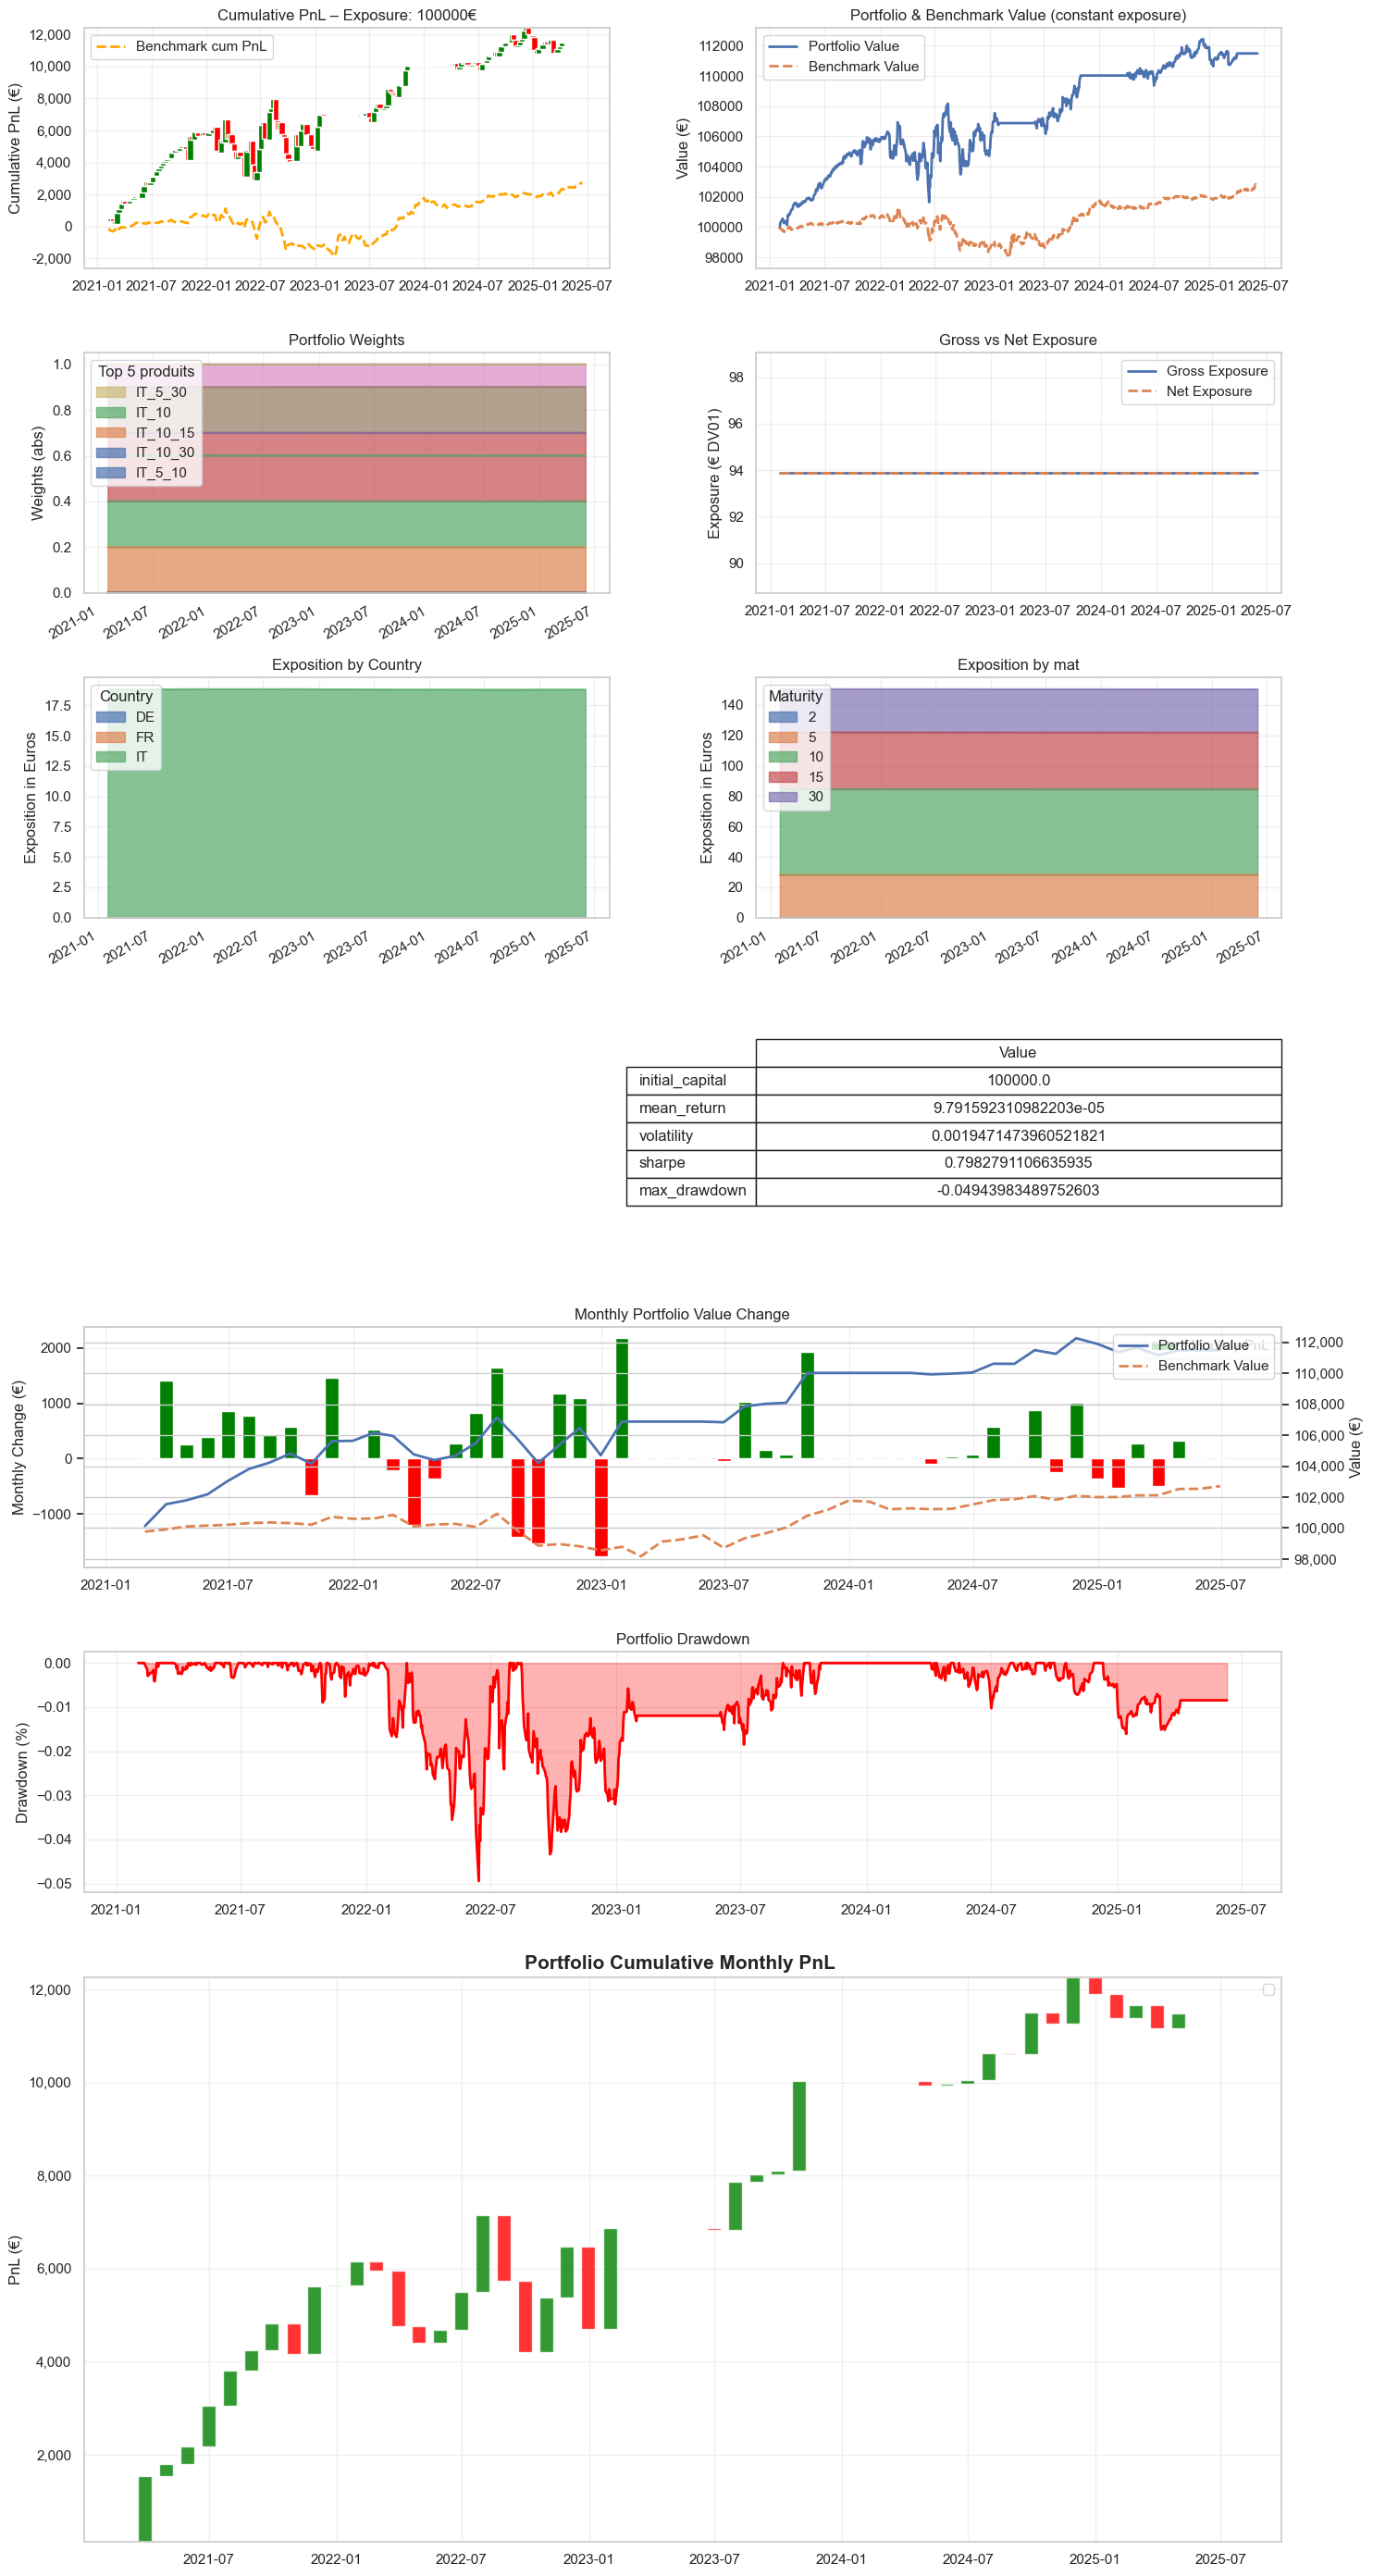

In [23]:
start_date = "2021-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    data=long_new,
    start_date="2021-01-01",
    end_date="2025-06-10",
    rebalance_freq="1M",
    long_only=True,
    lamb=0.5,
    span=60,
    tc_gamma=200,   # intensité des coûts dans l’optimisation
    initial_weights= df_weights["weight"]
)
tspf.dv01_by_product = dv01_by_product


tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(tspf)

viz.plot_dashboard()

## Anti LookAhead Test

In [24]:
def run_backtest(df_long, label):
    tspf_tmp = TimeSeriesPortfolio(
        data=df_long,
        start_date="2021-01-01",
        end_date="2025-06-10",
        rebalance_freq="1M",
        long_only=True,
        lamb=0.2,
        benchmark="ew",
        span=30,
        delta=0.1,
        tc_gamma=100,
        initial_weights=df_weights["weight"]
    )
    tspf_tmp.dv01_by_product = dv01_by_product
    tspf_tmp.generate_portfolios()

    pr = pd.Series(tspf_tmp.portfolio_returns).dropna().astype(float)
    vol = pr.std(ddof=0)
    sharpe = np.nan if vol < 1e-12 else (pr.mean()/vol)*np.sqrt(252)

    tc = pd.Series(tspf_tmp.metrics.get("transaction_costs", pd.Series(dtype=float)))
    pnl = pd.Series(tspf_tmp.metrics.get("portfolio_pnl", pd.Series(dtype=float)))

    return {
        "label": label,
        "n_obs": len(pr),
        "sharpe": float(sharpe),
        "mean_daily": float(pr.mean()),
        "vol_daily": float(vol),
        "max_drawdown": float(tspf_tmp.metrics.get("max_drawdown", np.nan)),
        "pnl_sum_net": float(pnl.sum()),   # dans ton code, portfolio_pnl est deja net
        "tc_sum": float(tc.sum()),
        "tspf": tspf_tmp
    }

base_df = long_new.copy()

#anti-lookahead: shift(1) par produit
lag_df = long_new.sort_values(["product", "time_stamp"]).copy()
lag_df["ret_total_per_dv01"] = (
    lag_df.groupby("product")["ret_total_per_dv01"].shift(1)
)
lag_df["ret_total_per_dv01"] = lag_df["ret_total_per_dv01"].fillna(0.0)

# Run
res_base = run_backtest(base_df, "baseline")
res_lag1 = run_backtest(lag_df, "lag1")

cmp = pd.DataFrame([res_base, res_lag1]).drop(columns=["tspf"])
print(cmp)

drop = (res_base["sharpe"] - res_lag1["sharpe"])
print("\nSharpe drop:", drop)

if np.isnan(res_lag1["sharpe"]):
    print("Verdict: invalide (lag1 non exploitable)")
elif res_lag1["sharpe"] > 0.5:
    print("Verdict: signal probablement robuste, pas de lookahead évident.")
elif res_lag1["sharpe"] > 0.2:
    print("Verdict: signal fragile mais plausible.")
else:
    print("Verdict: suspicion forte de contamination temporelle / lookahead.")


Optimisation échouée à 2021-02-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-03-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-04-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-05-31 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-08-02 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-11-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-05-31 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-06-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2023-06-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2023-10-02 00:00:00, on reprend les poids précédents
Tout a marché !!
Optimisation échouée à 2021-02-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-03-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-04-30 00:00:00, on reprend les poids précéd

## Run Diagnostic

In [25]:
# ═══════════════════════════════════════════════════════════════
# SHARPE DIAGNOSTIC — Is this Sharpe real?
# ═══════════════════════════════════════════════════════════════
import scipy.stats as stats

ret = tspf.portfolio_returns.dropna()
n_days = len(ret)
n_years = n_days / 252

print("=" * 65)
print("1. BASIC STATS")
print("=" * 65)
print(f"  Period:           {ret.index[0].date()} → {ret.index[-1].date()}")
print(f"  Trading days:     {n_days} ({n_years:.1f} years)")
print(f"  Daily mean:       {ret.mean():.6f}")
print(f"  Daily vol:        {ret.std():.6f}")
print(f"  Ann. return:      {ret.mean() * 252:.4f} ({ret.mean() * 252 * 100:.2f}%)")
print(f"  Ann. vol:         {ret.std() * np.sqrt(252):.4f} ({ret.std() * np.sqrt(252) * 100:.2f}%)")
print(f"  Sharpe (√252):    {ret.mean() / ret.std() * np.sqrt(252):.3f}")
print()

# --- Confidence interval on Sharpe ---
sr = ret.mean() / ret.std() * np.sqrt(252)
se_sr = np.sqrt((1 + 0.5 * sr**2) / n_days) * np.sqrt(252)
ci_lo, ci_hi = sr - 1.96 * se_sr, sr + 1.96 * se_sr
print(f"  Sharpe 95% CI:    [{ci_lo:.2f}, {ci_hi:.2f}]")
print(f"  Sharpe std err:   {se_sr:.3f}")
print()

print("=" * 65)
print("2. STABILITY — Rolling 1-Year Sharpe")
print("=" * 65)
rolling_sr = ret.rolling(252).apply(lambda x: x.mean() / x.std() * np.sqrt(252), raw=True)
yearly = ret.resample("YE").apply(lambda x: x.mean() / x.std() * np.sqrt(252) if len(x) > 20 else np.nan)
for yr, sr_yr in yearly.items():
    print(f"  {yr.year}:  Sharpe = {sr_yr:+.2f}")
print()

print("=" * 65)
print("3. DISTRIBUTION — Is it truly Gaussian?")
print("=" * 65)
skew = ret.skew()
kurt = ret.kurtosis()
jb_stat, jb_pval = stats.jarque_bera(ret.values)
print(f"  Skewness:         {skew:.3f}  (0 = symmetric)")
print(f"  Excess kurtosis:  {kurt:.3f}  (0 = Gaussian)")
print(f"  Jarque-Bera:      {jb_stat:.1f}  (p={jb_pval:.4f})")
print(f"  Max daily gain:   {ret.max():.6f}  ({ret.max() / ret.std():.1f}σ)")
print(f"  Max daily loss:   {ret.min():.6f}  ({ret.min() / ret.std():.1f}σ)")
print()

print("=" * 65)
print("4. DRAWDOWN ANALYSIS")
print("=" * 65)
cum = (1 + ret).cumprod()
dd = cum / cum.cummax() - 1
max_dd = dd.min()
max_dd_end = dd.idxmin()
max_dd_start = cum[:max_dd_end].idxmax()
recovery = cum[max_dd_end:][cum[max_dd_end:] >= cum[max_dd_start]]
recovery_date = recovery.index[0] if len(recovery) > 0 else "Not recovered"
print(f"  Max drawdown:     {max_dd:.4f} ({max_dd * 100:.2f}%)")
print(f"  DD peak:          {max_dd_start.date()}")
print(f"  DD trough:        {max_dd_end.date()}")
print(f"  Recovery:         {recovery_date if isinstance(recovery_date, str) else recovery_date.date()}")
print(f"  Calmar ratio:     {ret.mean() * 252 / abs(max_dd):.2f}")
print()

print("=" * 65)
print("5. TURNOVER & COSTS")
print("=" * 65)
w_hist = tspf.weights_history
turnover = w_hist.diff().abs().sum(axis=1).dropna()
tc_series = tspf.metrics.get("tc_series", pd.Series(dtype=float))
pf_pnl = tspf.metrics.get("portfolio_pnl", pd.Series(dtype=float))
total_pnl = pf_pnl.sum()
total_tc = tc_series.sum() if len(tc_series) > 0 else 0
print(f"  Avg turnover/reb: {turnover.mean():.3f}")
print(f"  Max turnover/reb: {turnover.max():.3f}")
print(f"  Total PnL (mid):  {total_pnl + total_tc:,.0f}€")
print(f"  Total TC paid:    {total_tc:,.0f}€")
print(f"  TC drag:          {total_tc / (total_pnl + total_tc) * 100:.1f}% of gross PnL" if total_pnl + total_tc != 0 else "N/A")
print(f"  Net PnL:          {total_pnl:,.0f}€")
print()

print("=" * 65)
print("6. AUTOCORRELATION — Serial dependence in returns?")
print("=" * 65)
for lag in [1, 5, 21]:
    ac = ret.autocorr(lag=lag)
    print(f"  Lag-{lag:>2d}:  {ac:+.4f}  {'⚠️ suspicious' if abs(ac) > 2 / np.sqrt(n_days) else '✓ within noise'}")
print()

print("=" * 65)
print("7. BENCHMARK COMPARISON")
print("=" * 65)
bm_ret = tspf.benchmark_returns.dropna()
bm_sr = bm_ret.mean() / bm_ret.std() * np.sqrt(252) if bm_ret.std() > 0 else 0
excess = ret - bm_ret.reindex(ret.index).fillna(0)
ir = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else 0
print(f"  Benchmark Sharpe: {bm_sr:.3f}")
print(f"  Information Ratio:{ir:.3f}")
print(f"  Excess return:    {excess.mean() * 252 * 100:.2f}% ann.")
print(f"  Tracking error:   {excess.std() * np.sqrt(252) * 100:.2f}% ann.")

1. BASIC STATS
  Period:           2021-02-02 → 2025-06-10
  Trading days:     1125 (4.5 years)
  Daily mean:       0.000098
  Daily vol:        0.001947
  Ann. return:      0.0247 (2.47%)
  Ann. vol:         0.0309 (3.09%)
  Sharpe (√252):    0.798

  Sharpe 95% CI:    [-0.27, 1.86]
  Sharpe std err:   0.543

2. STABILITY — Rolling 1-Year Sharpe
  2021:  Sharpe = +3.08
  2022:  Sharpe = -0.15
  2023:  Sharpe = +2.01
  2024:  Sharpe = +1.01
  2025:  Sharpe = -0.49

3. DISTRIBUTION — Is it truly Gaussian?
  Skewness:         -0.042  (0 = symmetric)
  Excess kurtosis:  8.579  (0 = Gaussian)
  Jarque-Bera:      3415.2  (p=0.0000)
  Max daily gain:   0.012988  (6.7σ)
  Max daily loss:   -0.013630  (-7.0σ)

4. DRAWDOWN ANALYSIS
  Max drawdown:     -0.0493 (-4.93%)
  DD peak:          2022-03-01
  DD trough:        2022-06-14
  Recovery:         2022-07-29
  Calmar ratio:     0.50

5. TURNOVER & COSTS
  Avg turnover/reb: 0.000
  Max turnover/reb: 0.001
  Total PnL (mid):  11,488€
  Total TC 

In [26]:
def _ann_sharpe(r, freq=252):
    r = pd.Series(r).dropna()
    vol = r.std(ddof=0)
    if len(r) == 0 or vol < 1e-12:
        return np.nan
    return (r.mean() / vol) * np.sqrt(freq)

def run_diagnostics(tspf, run_name="run"):
    pr = pd.Series(tspf.portfolio_returns).dropna().astype(float)
    br = pd.Series(tspf.benchmark_returns).reindex(pr.index).fillna(0.0).astype(float)

    m = getattr(tspf, "metrics", {})
    pnl = pd.Series(m.get("portfolio_pnl", pd.Series(dtype=float)))
    tc = pd.Series(m.get("transaction_costs", pd.Series(dtype=float)))
    gross = pd.Series(m.get("gross_exposure", pd.Series(dtype=float)))
    net = pd.Series(m.get("net_exposure", pd.Series(dtype=float)))

    if len(pnl) == 0:
        pnl = pd.Series(0.0, index=pr.index)
    else:
        pnl = pnl.reindex(pr.index).fillna(0.0)

    if len(tc) == 0:
        tc = pd.Series(0.0, index=pr.index)
    else:
        tc = tc.reindex(pr.index).fillna(0.0)

    wealth = (1 + pr).cumprod()
    drawdown = wealth / wealth.cummax() - 1

    stats = {
        "n_obs": float(len(pr)),
        "sharpe_ann": float(_ann_sharpe(pr)),
        "sharpe_ann_bench": float(_ann_sharpe(br)),
        "mean_daily": float(pr.mean()),
        "vol_daily": float(pr.std(ddof=0)),
        "max_drawdown": float(drawdown.min()) if len(drawdown) else np.nan,
        "pnl_sum": float(pnl.sum()),
        "tc_sum": float(tc.sum()),
        "pnl_minus_tc": float(pnl.sum() - tc.sum()),
        "pnl_plus_tc": float(pnl.sum() + tc.sum()),
        "tc_over_abs_pnl": float(tc.sum() / max(abs(pnl.sum()), 1e-12)),
        "net_exp_mean": float(net.mean()) if len(net) else np.nan,
        "gross_exp_mean": float(gross.mean()) if len(gross) else np.nan,
        "gross_exp_std": float(gross.std(ddof=0)) if len(gross) else np.nan,
        "corr_port_bench": float(pr.corr(br)) if len(pr) > 2 else np.nan,
    }

    turnover_stats = {}
    if hasattr(tspf, "weights_history") and isinstance(tspf.weights_history, pd.DataFrame) and not tspf.weights_history.empty:
        w = tspf.weights_history.sort_index().fillna(0.0)
        turnover = w.diff().abs().sum(axis=1).dropna()
        turnover_stats = {
            "turnover_mean": float(turnover.mean()) if len(turnover) else np.nan,
            "turnover_p95": float(turnover.quantile(0.95)) if len(turnover) else np.nan,
            "turnover_max": float(turnover.max()) if len(turnover) else np.nan,
        }

    out = pd.Series({**stats, **turnover_stats}, name=run_name)
    print(out.to_string(float_format=lambda x: f"{x:,.6f}"))

    if isinstance(pnl.index, pd.DatetimeIndex):
        monthly = pd.DataFrame({"pnl": pnl, "tc": tc}).resample("ME").sum()
        print("\nWorst 6 months (pnl):")
        print(monthly.sort_values("pnl").head(6))
        print("\nLast 6 months:")
        print(monthly.tail(6))

    return out

# Usage:
diag_current = run_diagnostics(tspf, "current_run")


n_obs               1,125.000000
sharpe_ann              0.798634
sharpe_ann_bench        0.447099
mean_daily              0.000098
vol_daily               0.001946
max_drawdown           -0.049300
pnl_sum            11,488.087766
tc_sum                 12.764948
pnl_minus_tc       11,475.322818
pnl_plus_tc        11,500.852715
tc_over_abs_pnl         0.001111
net_exp_mean           93.881154
gross_exp_mean         93.881154
gross_exp_std           0.000000
corr_port_bench         0.588841
turnover_mean           0.000093
turnover_p95            0.000174
turnover_max            0.000554

Worst 6 months (pnl):
                    pnl        tc
2022-12-31 -1764.493177  0.002049
2022-09-30 -1524.124249  0.002063
2022-08-31 -1411.749395  0.000000
2022-03-31 -1202.078606  0.001333
2021-10-31  -655.734497  0.001776
2025-01-31  -527.864662  0.001033

Last 6 months:
                   pnl        tc
2025-01-31 -527.864662  0.001033
2025-02-28  276.888688  0.001025
2025-03-31 -487.035909  0.0010

## Turnover Analysis

In [27]:
pr = pd.Series(tspf.portfolio_returns).dropna().astype(float).copy()
w = tspf.weights_history.sort_index().fillna(0.0)
turn = w.diff().abs().sum(axis=1).dropna()  # turnover aux dates de rebalance

turn_daily = pd.Series(0.0, index=pr.index)
common = turn.index.intersection(pr.index)
turn_daily.loc[common] = turn.loc[common].values

def ann_sharpe(r):
    r = pd.Series(r).dropna()
    return np.nan if r.std(ddof=0) < 1e-12 else (r.mean()/r.std(ddof=0))*np.sqrt(252)

grid_bps = [0, 1, 2, 5, 10, 20, 30, 50]  # bps par 100% turnover
rows = []
for bps in grid_bps:
    k = bps / 1e4
    r_net = pr - k * turn_daily
    rows.append({
        "tc_bps_per_100pct_turnover": bps,
        "sharpe_net": ann_sharpe(r_net),
        "mean_daily_net": r_net.mean(),
        "pnl_net_proxy": r_net.sum()
    })

sens = pd.DataFrame(rows)
print(sens)


   tc_bps_per_100pct_turnover  sharpe_net  mean_daily_net  pnl_net_proxy
0                           0    0.798634        0.000098       0.110155
1                           1    0.798631        0.000098       0.110155
2                           2    0.798627        0.000098       0.110154
3                           5    0.798616        0.000098       0.110153
4                          10    0.798599        0.000098       0.110150
5                          20    0.798563        0.000098       0.110146
6                          30    0.798528        0.000098       0.110141
7                          50    0.798457        0.000098       0.110131


In [28]:
# 1) initial_weights correctement indexés
w_init = df_weights.set_index("product")["weight"]

def run_case_with_params(data_in, start_date, end_date, label, params_local):
    tspf_tmp = TimeSeriesPortfolio(
        data=data_in,
        start_date=start_date,
        end_date=end_date,
        **params_local
    )
    tspf_tmp.dv01_by_product = dv01_by_product
    tspf_tmp.generate_portfolios()

    r = pd.Series(tspf_tmp.portfolio_returns).dropna().astype(float)
    s = r.std(ddof=0)
    sharpe = np.nan if s < 1e-12 else (r.mean()/s)*np.sqrt(252)

    pnl = pd.Series(tspf_tmp.metrics.get("portfolio_pnl", pd.Series(dtype=float)))
    tc  = pd.Series(tspf_tmp.metrics.get("transaction_costs", pd.Series(dtype=float)))
    w   = tspf_tmp.weights_history.fillna(0.0)

    return {
        "label": label,
        "n_obs": len(r),
        "sharpe": sharpe,
        "mean_daily": float(r.mean()) if len(r) else np.nan,
        "vol_daily": float(s) if len(r) else np.nan,
        "max_dd": float(tspf_tmp.metrics.get("max_drawdown", np.nan)),
        "pnl_sum": float(pnl.sum()),
        "tc_sum": float(tc.sum()),
        "turnover_mean": float(w.diff().abs().sum(axis=1).dropna().mean()) if not w.empty else np.nan,
        "gross_w_mean": float(w.abs().sum(axis=1).mean()) if not w.empty else np.nan,
        "obj": tspf_tmp,
    }

params2 = dict(
    rebalance_freq="1M",
    long_only=False,
    lamb=0.2,
    benchmark="ew",
    span=5,
    delta=0.5,
    tc_gamma=15000,
    initial_weights=w_init
)

BASE_DATA = long_new.copy()

# 2) Baseline full period
res_base = run_case_with_params(BASE_DATA, "2021-01-01", "2025-06-10", "baseline", params2)

# 3) Vrai OOS: train -> warm start OOS
res_train = run_case_with_params(BASE_DATA, "2021-01-01", "2023-12-31", "train", params2)
w_last = res_train["obj"].weights_history.iloc[-1] if not res_train["obj"].weights_history.empty else w_init

params_oos = params2.copy()
params_oos["initial_weights"] = w_last
res_oos = run_case_with_params(BASE_DATA, "2024-01-01", "2025-06-10", "oos", params_oos)

# 4) Placebo renforcé: on retire le drift cross-sectionnel puis shuffle
pl = BASE_DATA.copy()
pl["ret_total_per_dv01"] = pl.groupby("time_stamp")["ret_total_per_dv01"].transform(lambda x: x - x.mean())
pl["ret_total_per_dv01"] = pl.groupby("product")["ret_total_per_dv01"].transform(
    lambda s: s.sample(frac=1, random_state=42).values
)
res_placebo = run_case_with_params(pl, "2021-01-01", "2025-06-10", "placebo_cs_shuffle", params2)

out = pd.DataFrame([
    {k:v for k,v in res_base.items() if k!="obj"},
    {k:v for k,v in res_oos.items() if k!="obj"},
    {k:v for k,v in res_placebo.items() if k!="obj"},
])
print(out.to_string(index=False))


Tout a marché !!
Tout a marché !!
Tout a marché !!
Optimisation échouée à 2021-02-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-03-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-03-31 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-04-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-05-31 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-06-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-08-02 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-08-31 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-09-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-11-01 00:00:00, on reprend les poids précédents
Optimisation échouée à 2021-11-30 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-01-03 00:00:00, on reprend les poids précédents
Optimisation échouée à 2022-01-31 00:

In [29]:
# 1) Est-ce que l'optim utilise vraiment le signal ?
wb = res_base["obj"].weights_history.fillna(0.0)
wp = res_placebo["obj"].weights_history.reindex_like(wb).fillna(0.0)
cos = (wb*wp).sum(1) / (np.sqrt((wb**2).sum(1))*np.sqrt((wp**2).sum(1)) + 1e-12)
print("weight similarity baseline vs placebo:")
print(cos.describe())


weight similarity baseline vs placebo:
count    5.300000e+01
mean     1.000000e+00
std      4.768333e-09
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


C:\Users\thoma\AppData\Local\Temp\ipykernel_29960\2560883691.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cos = (wb*wp).sum(1) / (np.sqrt((wb**2).sum(1))*np.sqrt((wp**2).sum(1)) + 1e-12)
C:\Users\thoma\AppData\Local\Temp\ipykernel_29960\2560883691.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cos = (wb*wp).sum(1) / (np.sqrt((wb**2).sum(1))*np.sqrt((wp**2).sum(1)) + 1e-12)
C:\Users\thoma\AppData\Local\Temp\ipykernel_29960\2560883691.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cos = (wb*wp).sum(1) / (np.sqrt((wb**2).sum(1))*np.sqrt((wp**2).sum(1)) + 1e-12)


In [30]:
def ann_sharpe(r):
    r = pd.Series(r).dropna().astype(float)
    s = r.std(ddof=0)
    return np.nan if s < 1e-12 else (r.mean() / s) * np.sqrt(252)

def run_bt(df_long, start_date, end_date, params, dv01_by_product):
    tspf_tmp = TimeSeriesPortfolio(
        data=df_long,
        start_date=start_date,
        end_date=end_date,
        rebalance_freq=params["rebalance_freq"],
        long_only=params["long_only"],
        lamb=params["lamb"],
        benchmark=params["benchmark"],
        span=params["span"],
        delta=params["delta"],
        tc_gamma=params["tc_gamma"],
        initial_weights=params["initial_weights"],
    )
    tspf_tmp.dv01_by_product = dv01_by_product
    tspf_tmp.generate_portfolios()

    r = pd.Series(tspf_tmp.portfolio_returns).dropna().astype(float)
    pnl = pd.Series(tspf_tmp.metrics.get("portfolio_pnl", pd.Series(dtype=float)))
    tc  = pd.Series(tspf_tmp.metrics.get("transaction_costs", pd.Series(dtype=float)))
    w   = tspf_tmp.weights_history.fillna(0.0) if hasattr(tspf_tmp, "weights_history") else pd.DataFrame()

    return {
        "sharpe": ann_sharpe(r),
        "mean_daily": float(r.mean()) if len(r) else np.nan,
        "vol_daily": float(r.std(ddof=0)) if len(r) else np.nan,
        "max_dd": float(tspf_tmp.metrics.get("max_drawdown", np.nan)),
        "pnl_sum_net": float(pnl.sum()),
        "tc_sum": float(tc.sum()),
        "tc_over_abs_pnl": float(tc.sum() / max(abs(pnl.sum()), 1e-12)),
        "turnover_mean": float(w.diff().abs().sum(axis=1).dropna().mean()) if not w.empty else np.nan,
        "obj": tspf_tmp
    }

w_init = df_weights.set_index("product")["weight"]

params = dict(
    rebalance_freq="1M",
    long_only=False,     
    lamb=0.2,
    benchmark="ew",
    span=5,
    delta=0.5,
    tc_gamma=2000,        
    initial_weights=w_init
)

alphas = [0.0, 0.1, 0.2, 0.35, 0.5, 0.75, 1]
rows = []

for a in alphas:
    df = long.copy()
    add = long_roll[["time_stamp", "product", "roll_ortho_bp_prod"]].copy()
    add["time_stamp"] = pd.to_datetime(add["time_stamp"])
    df["time_stamp"] = pd.to_datetime(df["time_stamp"])

    df = df.merge(add, on=["time_stamp", "product"], how="left")
    df["roll_ortho_bp_prod"] = df["roll_ortho_bp_prod"].fillna(0.0)
    df["ret_total_per_dv01"] = df["ret_total_per_dv01"] + a * df["roll_ortho_bp_prod"]

    # baseline full sample
    base = run_bt(df, "2021-01-01", "2025-06-10", params, dv01_by_product)

    # OOS with warm start from train
    train = run_bt(df, "2021-01-01", "2023-12-31", params, dv01_by_product)
    w_last = train["obj"].weights_history.iloc[-1] if not train["obj"].weights_history.empty else w_init
    params_oos = params.copy()
    params_oos["initial_weights"] = w_last
    oos = run_bt(df, "2024-01-01", "2025-06-10", params_oos, dv01_by_product)

    # placebo (shuffle cross-section by date)
    pl = df.copy()
    pl["ret_total_per_dv01"] = pl.groupby("time_stamp")["ret_total_per_dv01"].transform(
        lambda s: s.sample(frac=1, random_state=42).values
    )
    placebo = run_bt(pl, "2021-01-01", "2025-06-10", params, dv01_by_product)

    rows.append({
        "alpha_roll": a,
        "sharpe_base": base["sharpe"],
        "sharpe_oos": oos["sharpe"],
        "sharpe_placebo": placebo["sharpe"],
        "maxdd_base": base["max_dd"],
        "tc_over_abs_pnl_base": base["tc_over_abs_pnl"],
        "turnover_base": base["turnover_mean"],
        "pnl_base": base["pnl_sum_net"],
        "pnl_oos": oos["pnl_sum_net"],
    })

res = pd.DataFrame(rows).sort_values("alpha_roll")
print(res.to_string(index=False))

# Simple decision score (customize)
res["score"] = (
    1.0 * res["sharpe_oos"].fillna(-999)
    + 0.3 * res["sharpe_base"].fillna(-999)
    - 0.5 * res["sharpe_placebo"].fillna(0)
    - 0.2 * res["tc_over_abs_pnl_base"].fillna(999)
)
print("\nBest by score:")
print(res.sort_values("score", ascending=False).head(3).to_string(index=False))


Tout a marché !!
Tout a marché !!
Tout a marché !!
Optimisation échouée à 2021-06-30 00:00:00, on reprend les poids précédents
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Optimisation échouée à 2021-11-30 00:00:00, on reprend les poids précédents
Tout a marché !!
Optimisation échouée à 2021-11-30 00:00:00, on reprend les poids précédents
Tout a marché !!
Tout a marché !!
Optimisation échouée à 2021-11-30 00:00:00, on reprend les poids précédents
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
Tout a marché !!
 alpha_roll  sharpe_base  sharpe_oos  sharpe_placebo  maxdd_base  tc_over_abs_pnl_base  turnover_base    pnl_base     pnl_oos
       0.00     0.677316    0.233257       -0.018198   -0.016704              0.017437       0

In [31]:
# Split temporel : train 2021-2023, test 2024-2025
for cov_method in ["ledoit", "factor"]:
    tspf_train = TimeSeriesPortfolio(
        data=long_new, start_date="2021-01-01", end_date="2023-12-31",
        rebalance_freq="1M", long_only=True, lamb=0.2, benchmark="ew",
        span=5, delta=0.1, tc_gamma=1.0, initial_weights=df_weights["weight"],
    )
    tspf_train.dv01_by_product = dv01_by_product
    tspf_train.generate_portfolios()
    r_train = tspf_train.portfolio_returns.dropna()
    sr_train = r_train.mean() / r_train.std() * np.sqrt(252)

    tspf_test = TimeSeriesPortfolio(
        data=long_new, start_date="2024-01-01", end_date="2025-06-10",
        rebalance_freq="1M", long_only=True, lamb=0.2, benchmark="ew",
        span=5, delta=0.1, tc_gamma=1.0, initial_weights=df_weights["weight"],
    )
    tspf_test.dv01_by_product = dv01_by_product
    tspf_test.generate_portfolios()
    r_test = tspf_test.portfolio_returns.dropna()
    sr_test = r_test.mean() / r_test.std() * np.sqrt(252)

    print(f"{cov_method:>8s}  train Sharpe={sr_train:.2f}  test Sharpe={sr_test:.2f}  decay={sr_train - sr_test:.2f}")

Tout a marché !!
Optimisation échouée à 2024-05-31 00:00:00, on reprend les poids précédents
Tout a marché !!
  ledoit  train Sharpe=2.68  test Sharpe=2.54  decay=0.14
Tout a marché !!
Optimisation échouée à 2024-05-31 00:00:00, on reprend les poids précédents
Tout a marché !!
  factor  train Sharpe=2.68  test Sharpe=2.54  decay=0.14
